# --- INFO DATASET ---

## Valuta 10 obiettivi chiave
L’OHI non misura un solo aspetto, ma combina 10 obiettivi che rappresentano i principali benefici che l’oceano fornisce all’umanità:
	1.	Produzione alimentare (pesca + maricoltura)
	2.	Opportunità di pesca artigianale
	3.	Prodotti naturali
	4.	Stoccaggio del carbonio
	5.	Protezione costiera
	6.	Livello di pulizia delle acque
	7.	Biodiversità
	8.	Mezzi di sussistenza e economie locali
	9.	Identità culturale
	10.	Turismo e ricreazione

Ogni obiettivo viene valutato con un punteggio da 0 a 100.

## Ogni obiettivo viene calcolato con 3 dimensioni
Per ciascun obiettivo si considera:
- Punteggio attuale – lo stato attuale rispetto a un target sostenibile.
- Tendenza – se la situazione sta migliorando o peggiorando.
- Pressioni – fattori negativi (inquinamento, sovrasfruttamento, acidificazione…).
- Resilienza – fattori positivi (aree protette, buone politiche, ripristino habitat…).

## I dati vengono standardizzati
Il valore per ogni obiettivo è convertito in un punteggio su 100, dove:
- 100 = oceano in condizioni ideali e pienamente sostenibile
- 0 = oceano gravemente compromesso

## Il punteggio finale è una media ponderata
L’indice OHI complessivo per una nazione o una regione è ottenuto combinando i punteggi dei 10 obiettivi.

    OHI = media ponderata dei 10 punteggi

Le ponderazioni tengono conto dell’importanza relativa degli obiettivi.

## Perché è importante?
- Mostra quanto gli oceani sono in grado di supportare l’umanità.
- Permette confronti tra paesi e regioni.
- Aiuta a identificare interventi prioritari (pesca sostenibile, aree protette, gestione costiera…).
- Integra ecologia + economia + società, cosa rara negli indici ambientali.

# --- Analisi e Pulizia dei Dati ---

In [232]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

In [233]:
df = pd.read_csv("Ocean_Health_Index.csv")
print("Dataset caricato con successo.")

print("\n--- Anteprima dataset ---")
display(df.head())

print("\n--- Info dataset ---")
display(df.info())

print("\n--- Statistiche descrittive dataset ---")
display(df.describe())

print("\n--- Conteggio valori nulli ---")
display(df.isna().sum())

Dataset caricato con successo.

--- Anteprima dataset ---


,REF_AREA,REF_AREA_LABEL,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,ABW,Aruba,70.79,70.10,70.09,70.52,71.28,72.14,77.65,80.87,79.94,79.39,76.43,64.90,67.50
1,AGO,Angola,63.33,64.57,64.57,67.00,67.66,66.70,65.71,61.90,59.76,59.23,59.41,57.91,57.89
2,AIA,Anguilla,72.17,70.60,70.82,70.86,70.74,70.21,70.36,70.30,70.36,70.35,70.44,70.63,70.87
3,ALB,Albania,62.95,63.27,63.86,66.55,66.16,66.70,67.38,67.52,71.79,71.70,71.19,65.38,69.68
4,ANT,Netherlands Antilles,74.66,74.98,74.97,74.92,77.45,77.45,77.44,77.44,76.61,76.51,76.33,76.35,76.34



--- Info dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   REF_AREA        194 non-null    object 
 1   REF_AREA_LABEL  194 non-null    object 
 2   2012            194 non-null    float64
 3   2013            194 non-null    float64
 4   2014            194 non-null    float64
 5   2015            194 non-null    float64
 6   2016            194 non-null    float64
 7   2017            194 non-null    float64
 8   2018            194 non-null    float64
 9   2019            194 non-null    float64
 10  2020            194 non-null    float64
 11  2021            194 non-null    float64
 12  2022            194 non-null    float64
 13  2023            194 non-null    float64
 14  2024            194 non-null    float64
dtypes: float64(13), object(2)
memory usage: 22.9+ KB


None


--- Statistiche descrittive dataset ---


,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
count,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000
mean,69.138144,69.758299,70.184742,70.746031,70.863247,70.788247,70.984536,71.217320,71.448144,71.356649,71.382062,66.585361,66.761649
std,5.969848,5.936358,6.010257,6.019021,6.025836,6.173841,6.195274,6.175477,6.139694,6.160548,6.234617,6.643286,6.602835
min,48.670000,48.780000,50.870000,51.230000,50.930000,51.110000,52.160000,51.520000,49.620000,49.250000,49.140000,47.540000,46.870000
25%,65.105000,65.440000,66.080000,66.992500,67.337500,67.337500,67.607500,67.932500,68.177500,68.335000,68.600000,62.330000,62.960000
50%,69.665000,70.135000,70.605000,71.120000,71.185000,71.200000,71.450000,71.770000,71.765000,71.620000,71.540000,66.640000,66.645000
75%,72.875000,73.425000,74.202500,74.872500,74.777500,74.825000,75.162500,75.227500,75.205000,75.167500,75.377500,71.155000,70.867500
max,82.740000,82.130000,83.060000,83.490000,83.440000,84.350000,85.030000,85.070000,86.920000,86.790000,86.320000,84.600000,83.460000



--- Conteggio valori nulli ---


REF_AREA          0
REF_AREA_LABEL    0
2012              0
2013              0
2014              0
2015              0
2016              0
2017              0
2018              0
2019              0
2020              0
2021              0
2022              0
2023              0
2024              0
dtype: int64

### Colonne

- REF_AREA: 3-letter country code
- REF_AREA_LABEL: Country name
- year: Annual Ocean Health Index scores (0-100 scale)

### Osservazioni

- nessun valore nullo
- year numerico -> OK
- year: max e min nel range 0-100 -> OK

### Da cambiare

- year: ogni anno è una colonna -> prendo le colonne degli anni e le trasformo in righe

## Faccio il cambio su year

In [234]:
df_new = df.melt(
    id_vars=["REF_AREA", "REF_AREA_LABEL"],
    var_name="Year",
    value_name="OHI" # Ocean Health Index
)

df_new["Year"] = df_new["Year"].astype(int)

print("--- Anteprima dataset ristrutturato ---")
display(df_new.head(15))

--- Anteprima dataset ristrutturato ---


,REF_AREA,REF_AREA_LABEL,Year,OHI
0,ABW,Aruba,2012,70.79
1,AGO,Angola,2012,63.33
2,AIA,Anguilla,2012,72.17
3,ALB,Albania,2012,62.95
4,ANT,Netherlands Antilles,2012,74.66
5,ARE,United Arab Emirates,2012,82.74
6,ARG,Argentina,2012,65.39
7,ASC,Ascension Island,2012,72.62
8,ASM,American Samoa,2012,75.13
9,ATG,Antigua and Barbuda,2012,78.20


## Elimino la riga che prende il mondo

In [235]:
index_to_drop = df_new[df_new["REF_AREA"] == "WLD"].index

df_new = df_new.drop(index_to_drop)

# --- Primi Grafici ---

## Trend temporale OHI medio globale

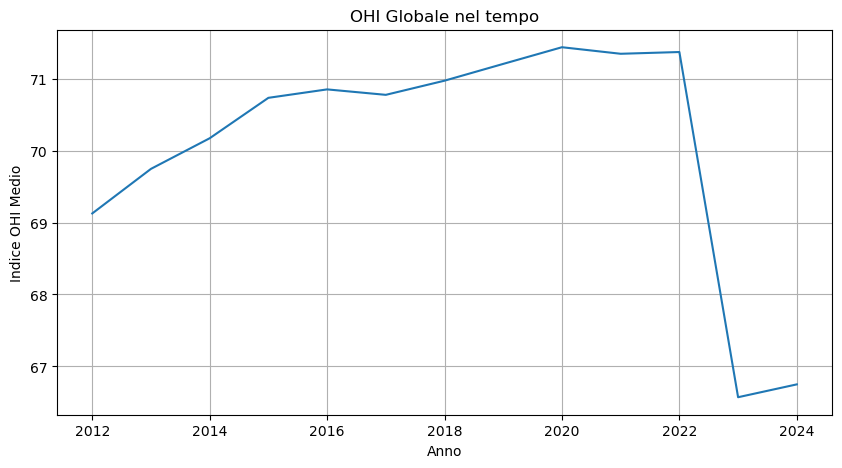

In [236]:
df_yearly = df_new.groupby("Year")["OHI"].mean()

plt.figure(figsize=(10,5))
df_yearly.plot()

plt.title("OHI Globale nel tempo")
plt.xlabel("Anno")
plt.ylabel("Indice OHI Medio")
plt.grid(True)
plt.show()


## Confronto tra paesi - top 5 per media OHI

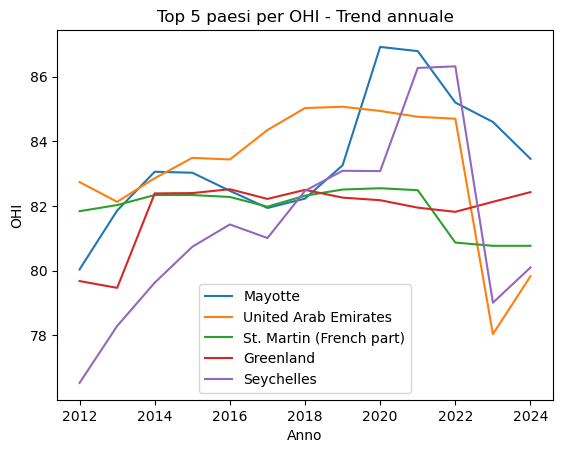

In [237]:
top_countries = (
    df_new.groupby("REF_AREA_LABEL")["OHI"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

for c in top_countries:
    subset = df_new[df_new["REF_AREA_LABEL"] == c]
    plt.plot(subset["Year"], subset["OHI"], label=c)

plt.legend()
plt.title("Top 5 paesi per OHI - Trend annuale")
plt.xlabel("Anno")
plt.ylabel("OHI")
plt.show()

## Heatmap

Così posso vedere:

- il lungo termine
    - paesi che migliorano -> colore che cambia
    - paesi che peggiorano -> colore che diventa scuro
    - stabilità -> colore uniforme nel tempo

- confronto tra paesi
    - paesi con OHI alto -> chiari
    - paesi con OHI basso -> scuri

- anomalie
    - errori nei dati
    - disastri naturali
    - cambiamenti politici
    - nuovi programmi di conservazione

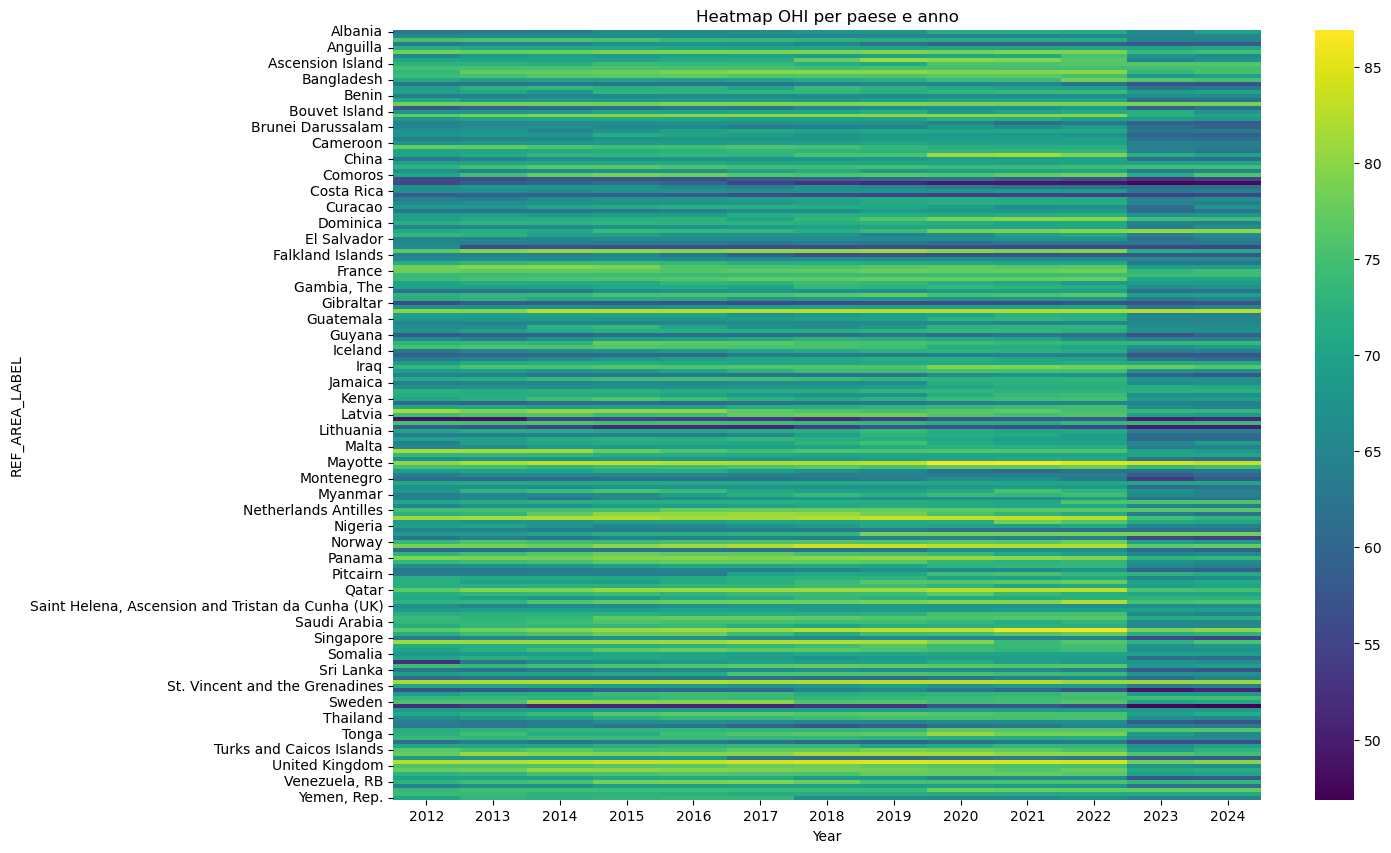

In [238]:
pivot = df_new.pivot(index="REF_AREA_LABEL", columns="Year", values="OHI")

plt.figure(figsize=(14,10))
sns.heatmap(pivot, cmap="viridis")
plt.title("Heatmap OHI per paese e anno")
plt.show()


# --- Analisi pre, durante e post COVID-19 ---

In [239]:
# Pre-COVID: 2012–2019
pre = df_new[(df_new["Year"] >= 2012) & (df_new["Year"] <= 2019)]["OHI"].mean()

# Durante COVID: 2020–2021
durante = df_new[(df_new["Year"] >= 2020) & (df_new["Year"] <= 2021)]["OHI"].mean()

# Post-COVID: 2022–2024
post = df_new[(df_new["Year"] >= 2022) & (df_new["Year"] <= 2024)]["OHI"].mean()

print("Pre-COVID:", pre)
print("Durante COVID:", durante)
print("Post-COVID:", post)


Pre-COVID: 70.44663860103628
Durante COVID: 71.39007772020726
Post-COVID: 68.23093264248705


## Grafico a barre

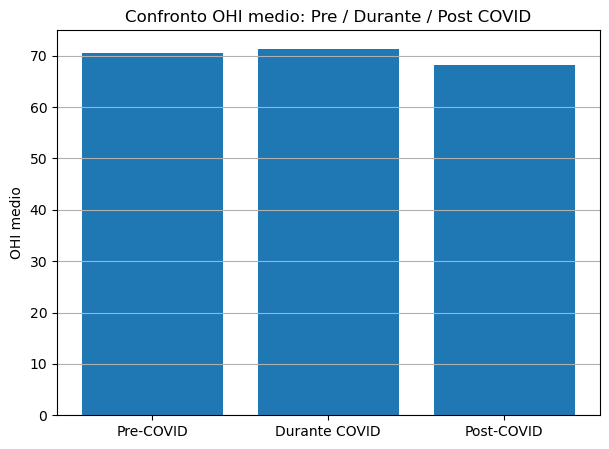

In [240]:
valori = [pre, durante, post]
periodi = ["Pre-COVID", "Durante COVID", "Post-COVID"]

plt.figure(figsize=(7,5))
plt.bar(periodi, valori)
plt.title("Confronto OHI medio: Pre / Durante / Post COVID")
plt.ylabel("OHI medio")
plt.grid(axis="y")
plt.show()


## Trend globale con aree colorate

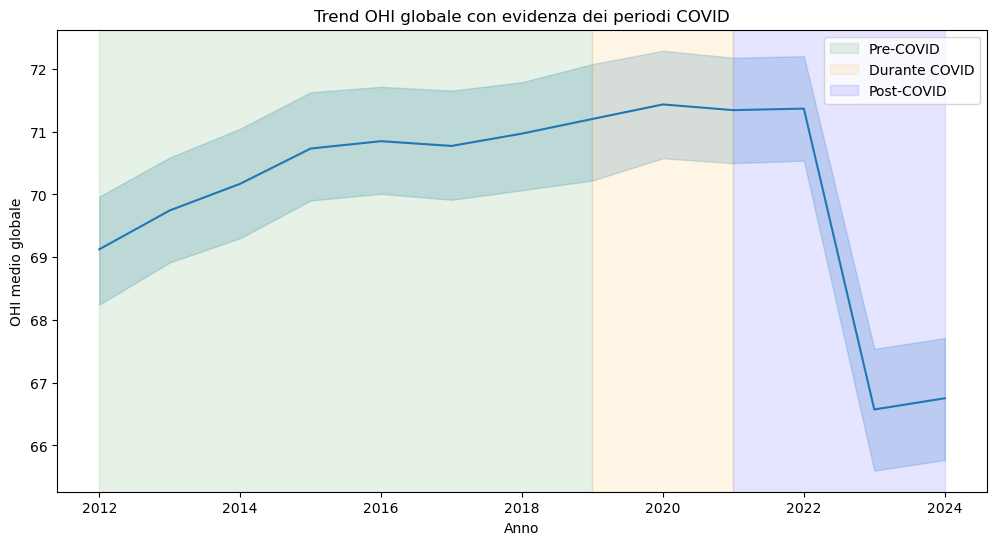

In [241]:
plt.figure(figsize=(12,6))

# Linea del trend
sns.lineplot(data=df_new, x="Year", y="OHI", estimator='mean')

# Aree colorate
plt.axvspan(2012, 2019, alpha=0.1, color="green", label="Pre-COVID")
plt.axvspan(2019, 2021, alpha=0.1, color="orange", label="Durante COVID")
plt.axvspan(2021, 2024, alpha=0.1, color="blue", label="Post-COVID")

plt.title("Trend OHI globale con evidenza dei periodi COVID")
plt.xlabel("Anno")
plt.ylabel("OHI medio globale")
plt.legend()
plt.show()


## Confronto per paesi

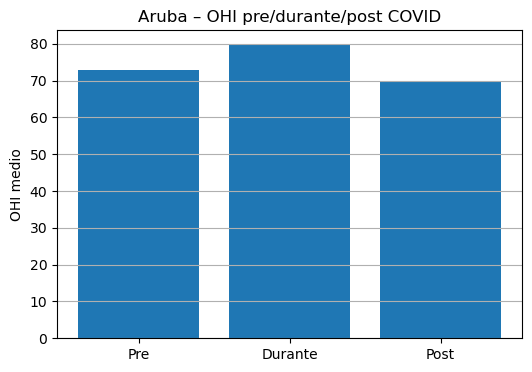

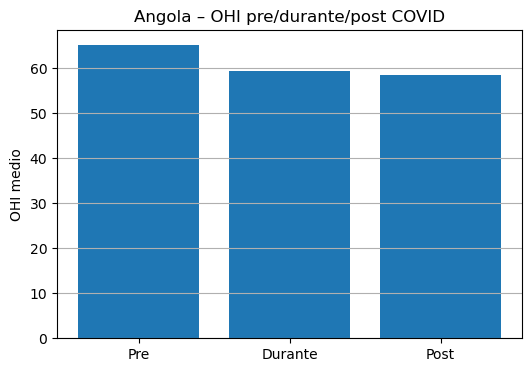

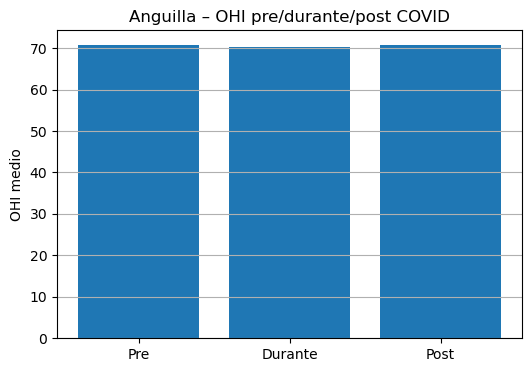

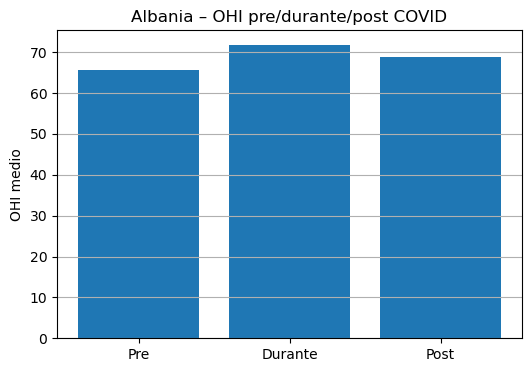

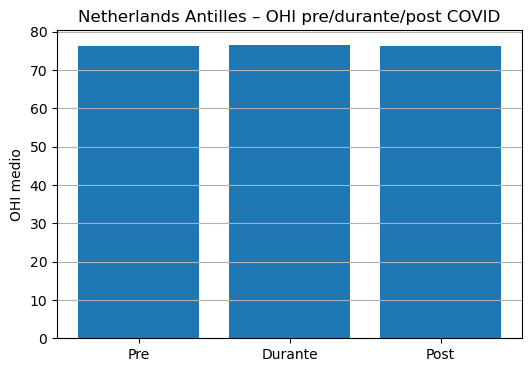

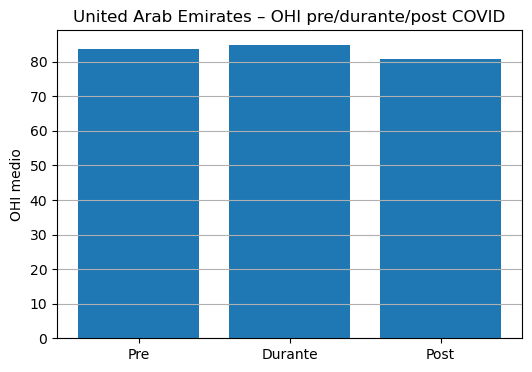

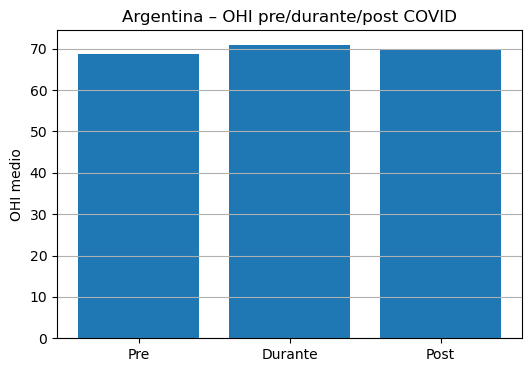

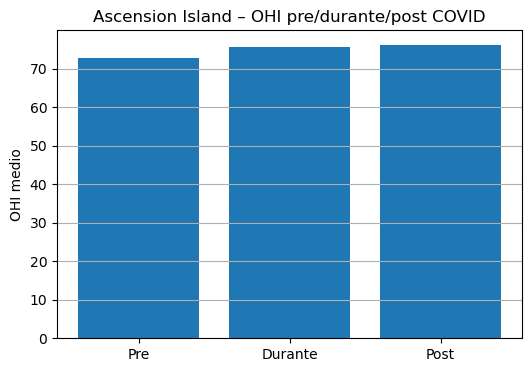

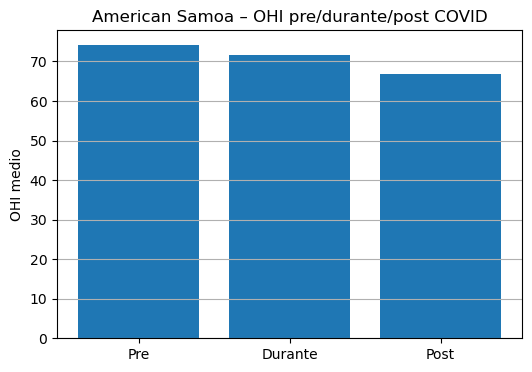

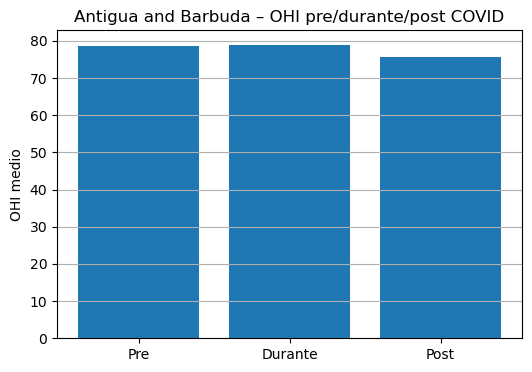

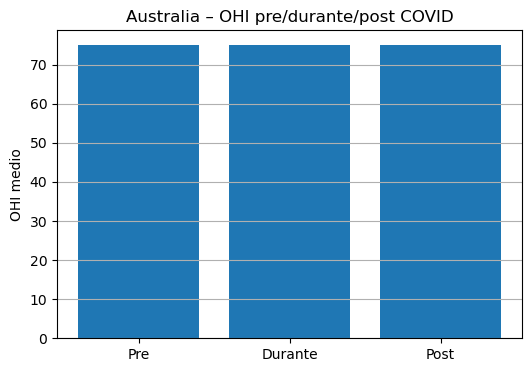

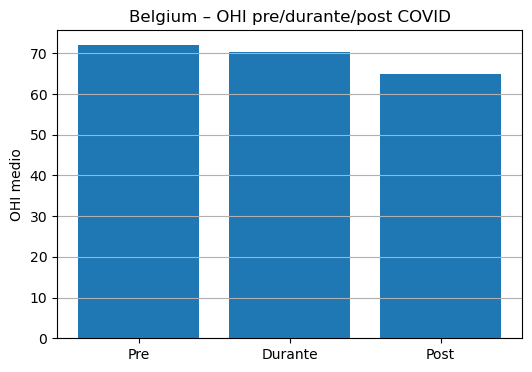

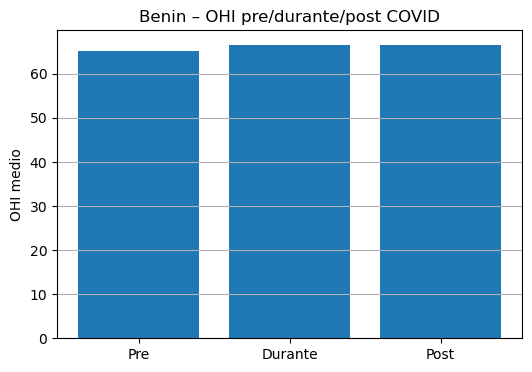

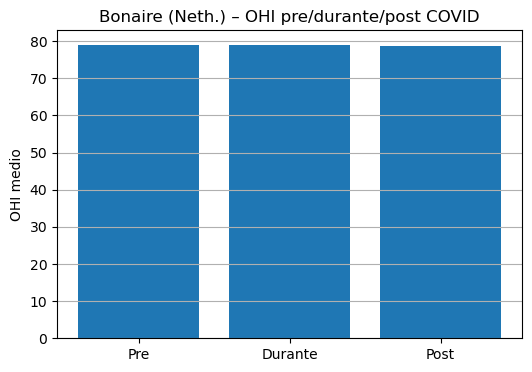

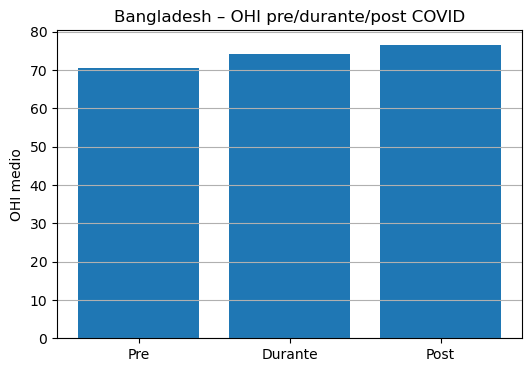

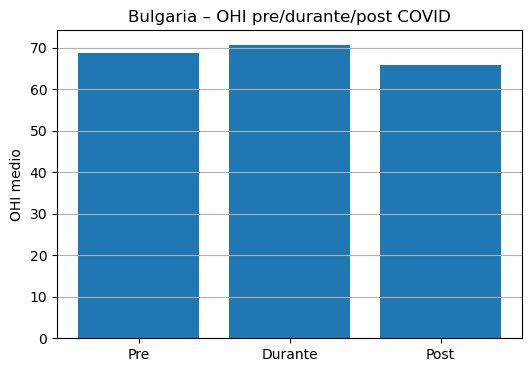

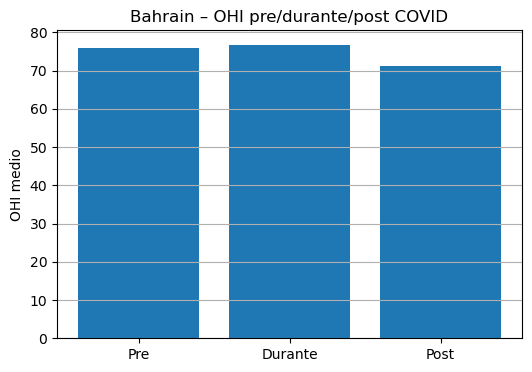

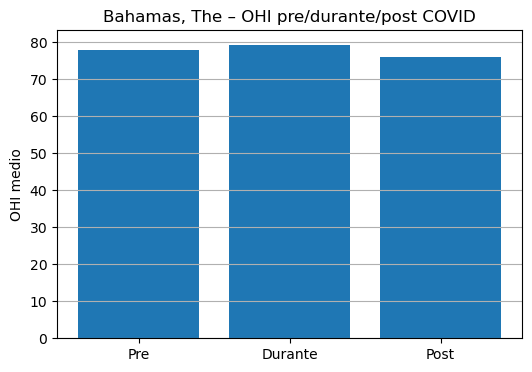

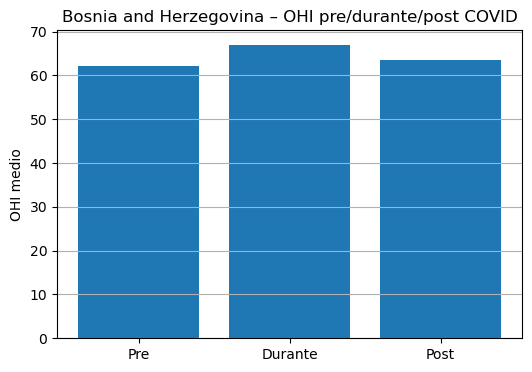

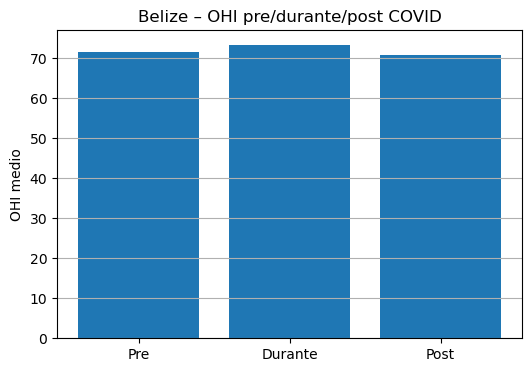

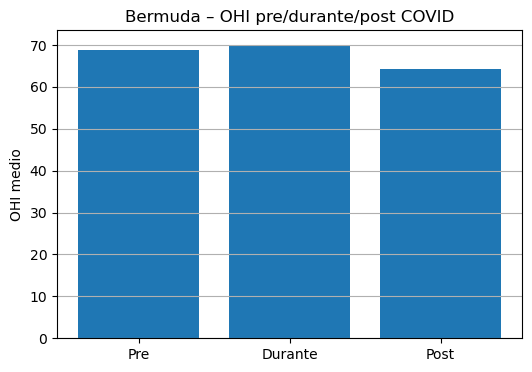

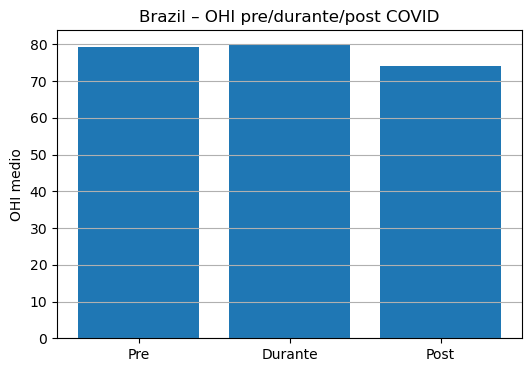

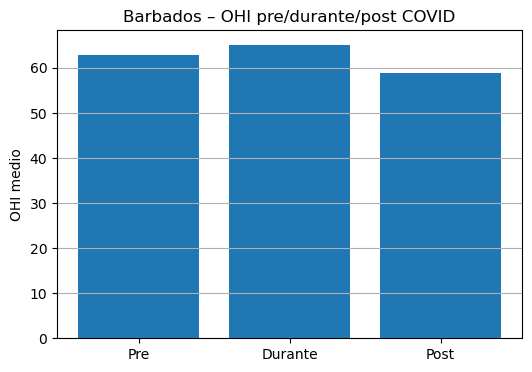

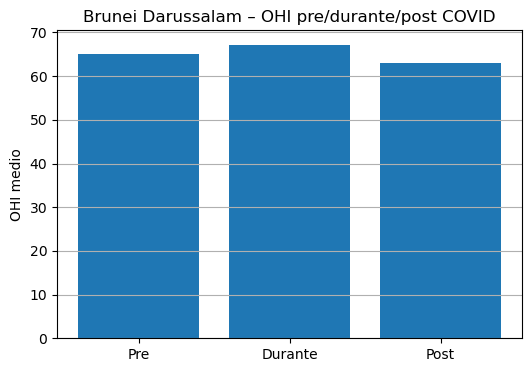

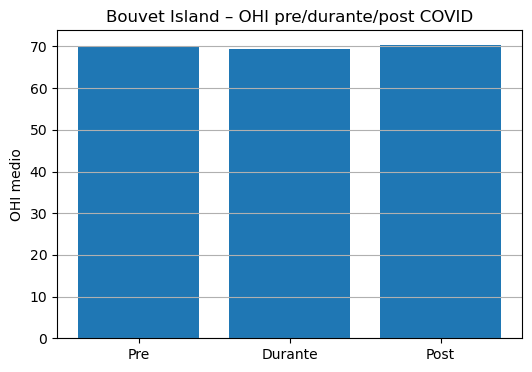

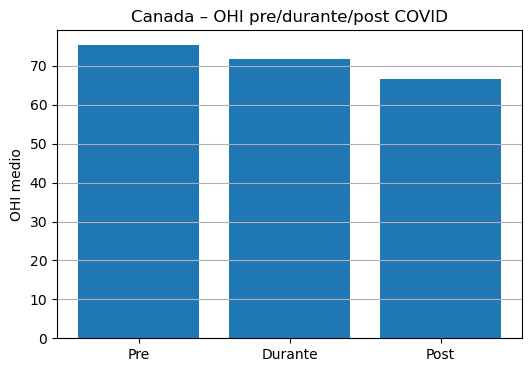

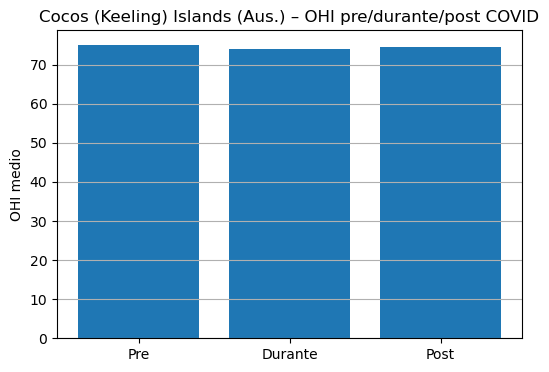

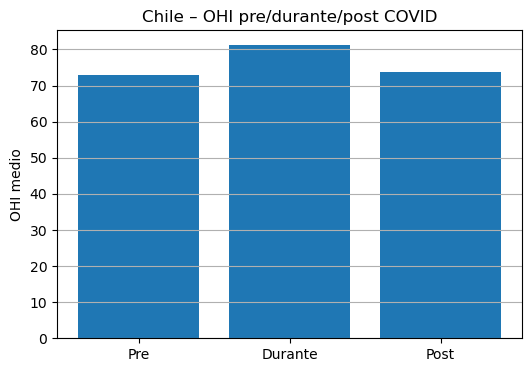

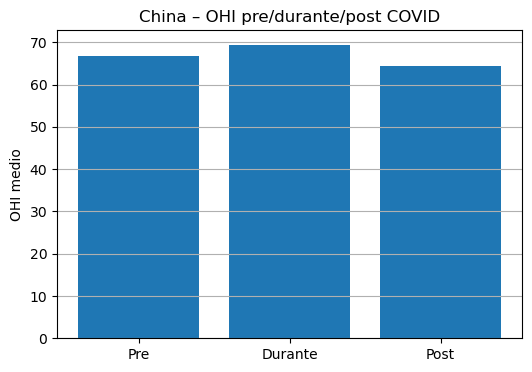

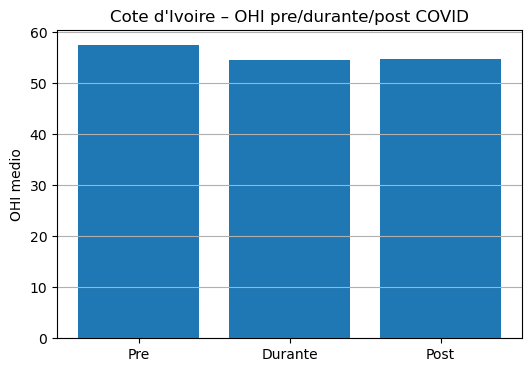

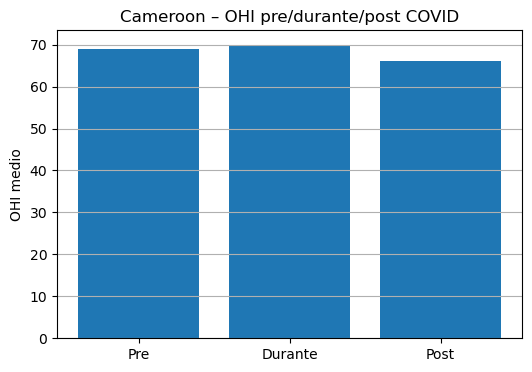

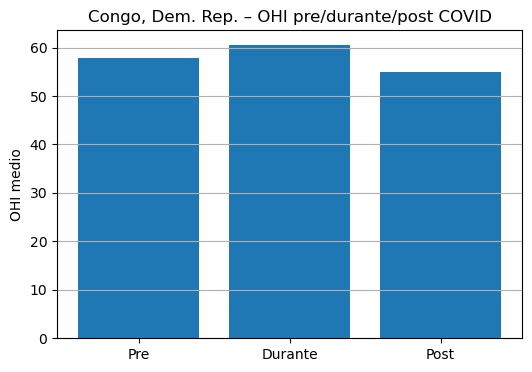

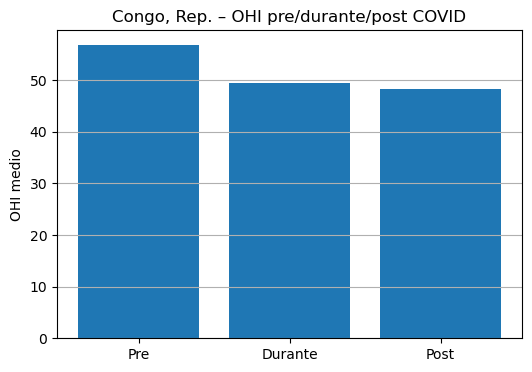

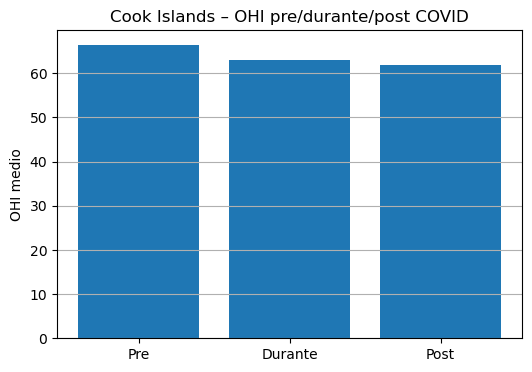

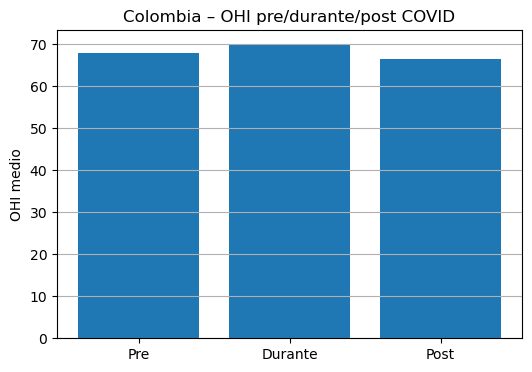

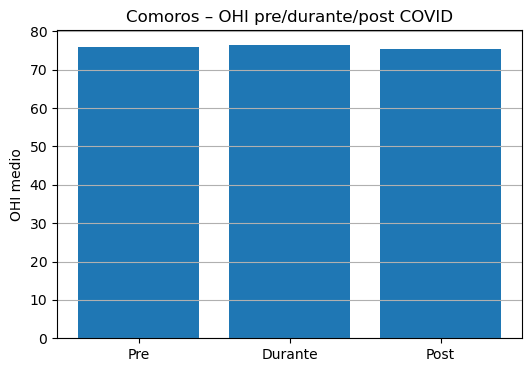

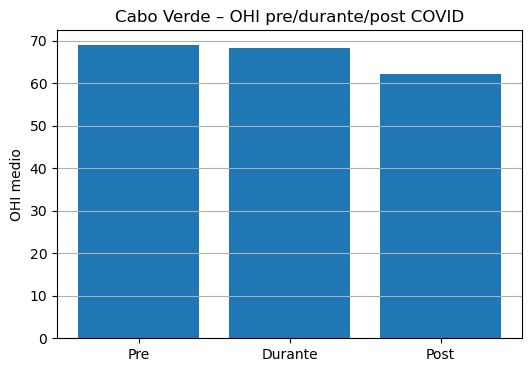

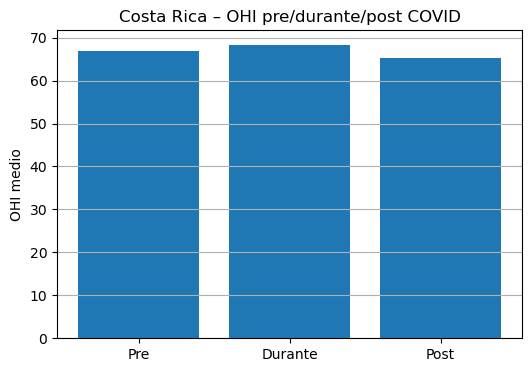

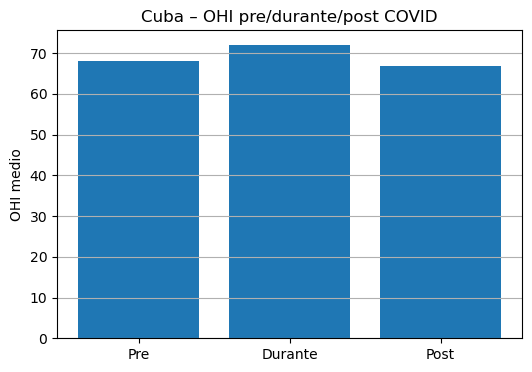

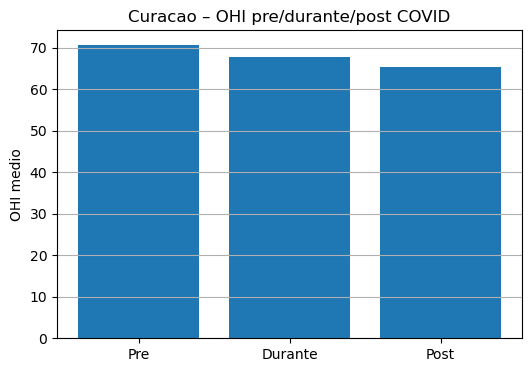

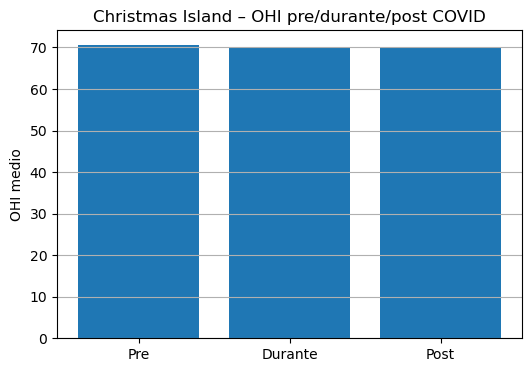

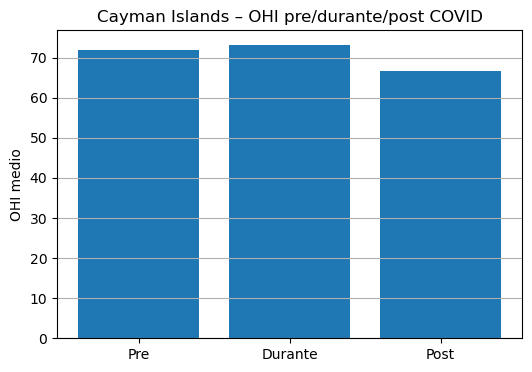

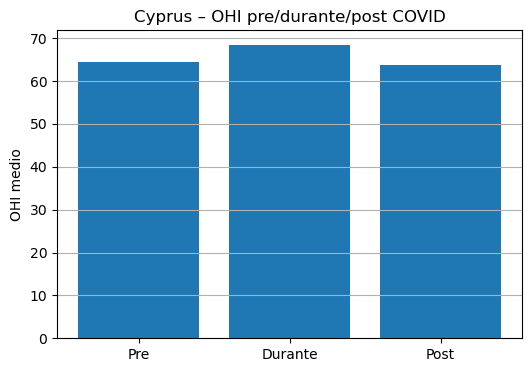

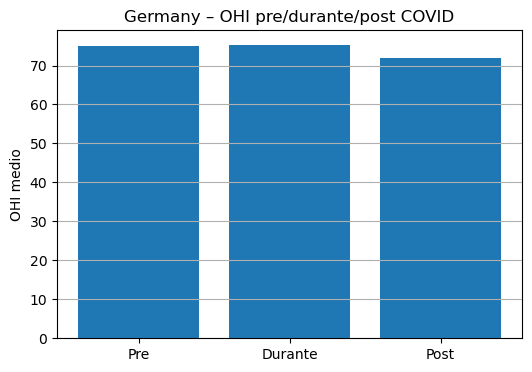

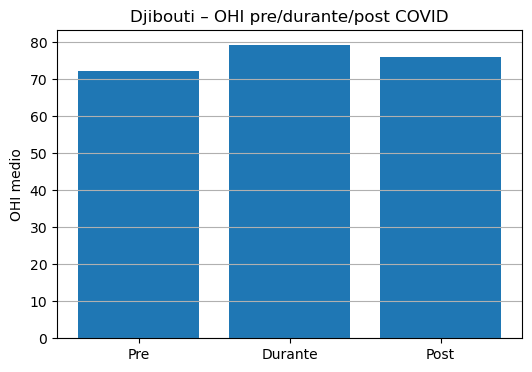

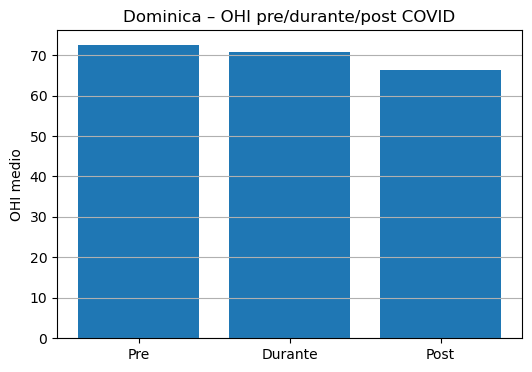

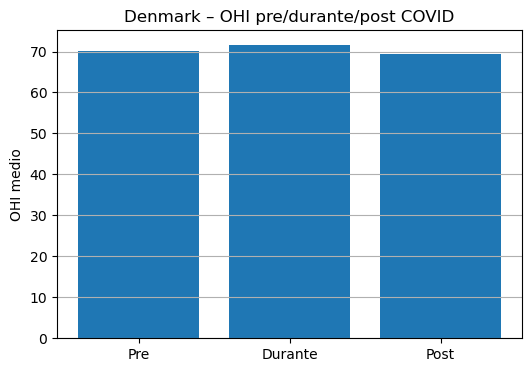

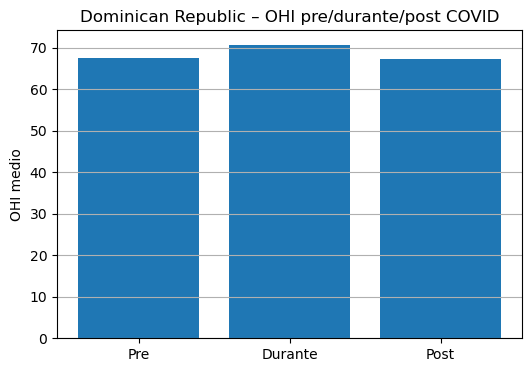

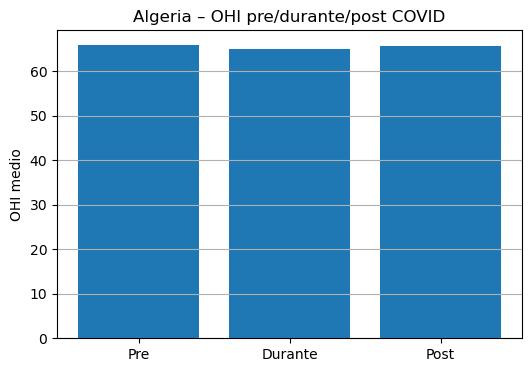

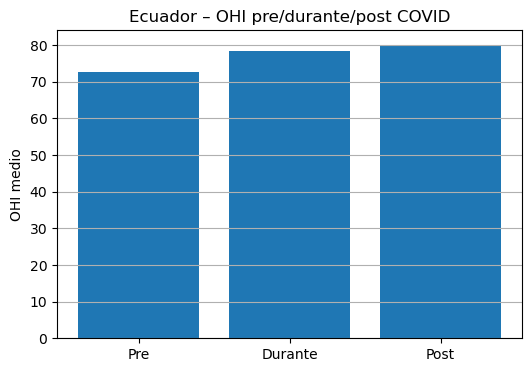

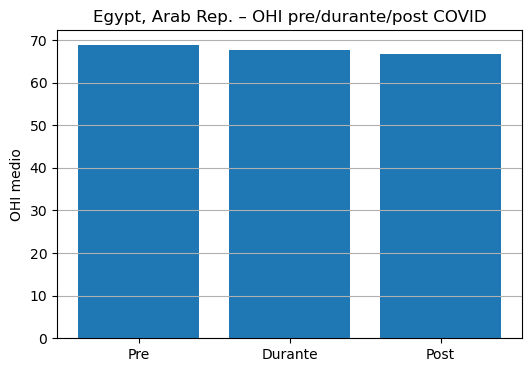

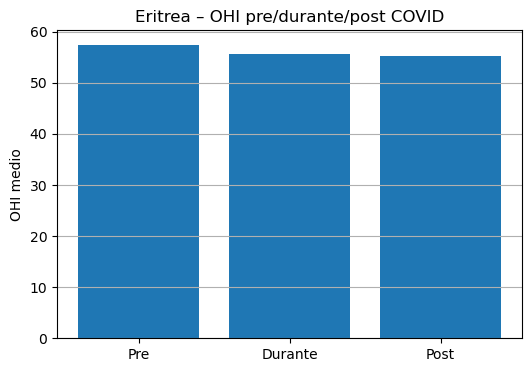

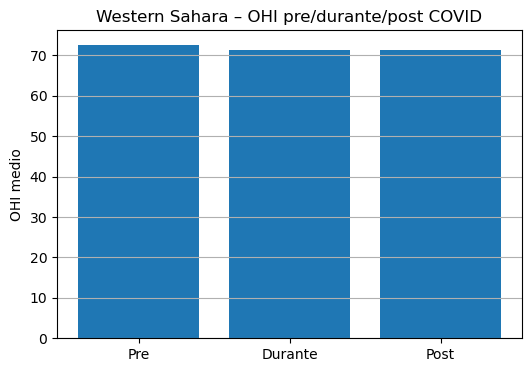

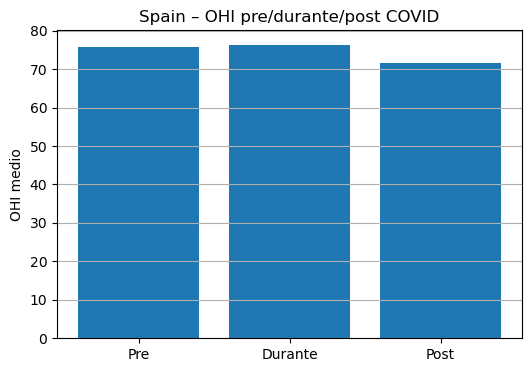

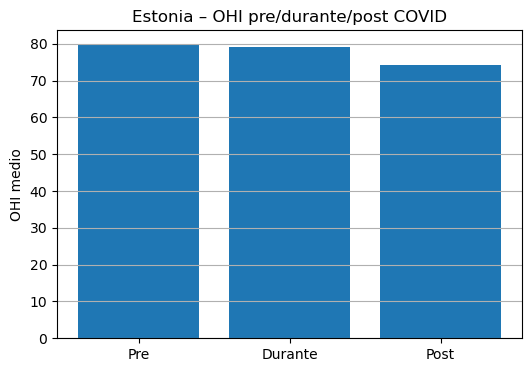

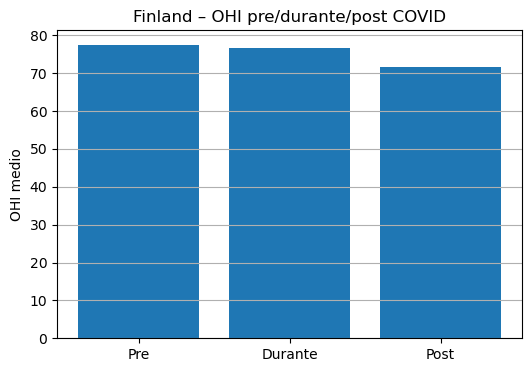

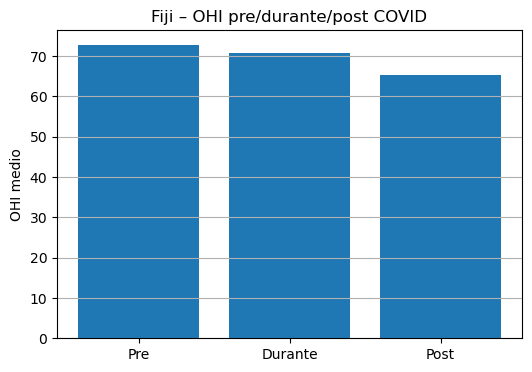

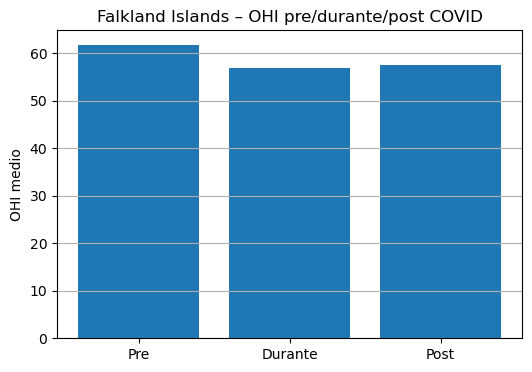

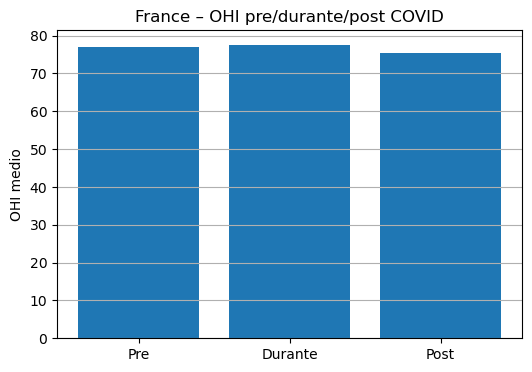

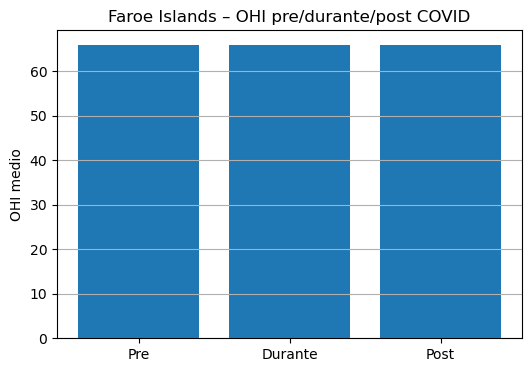

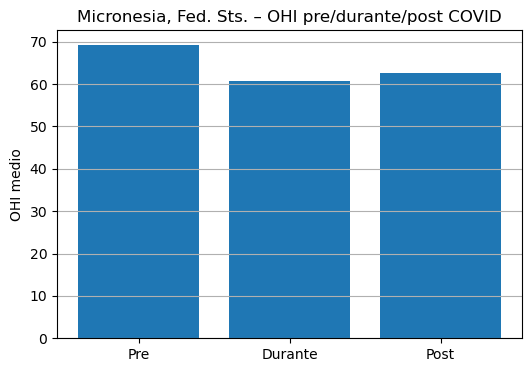

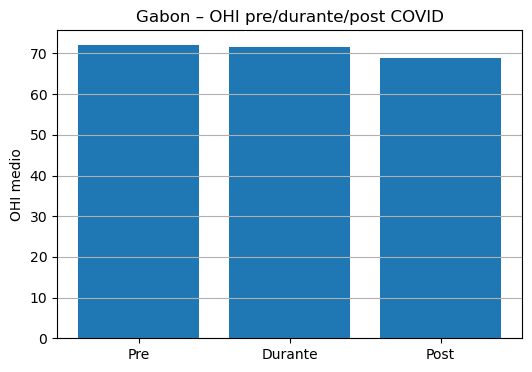

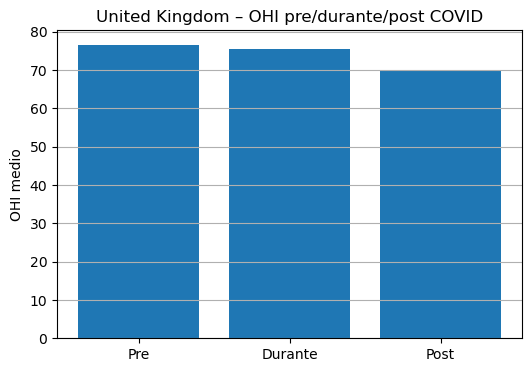

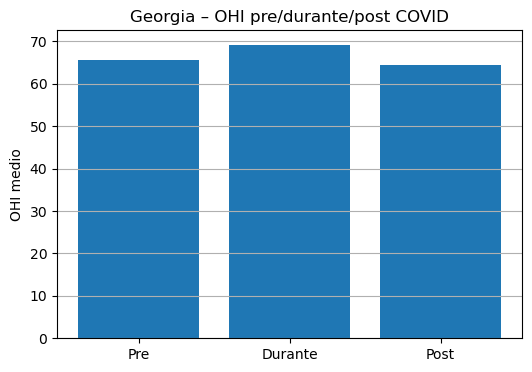

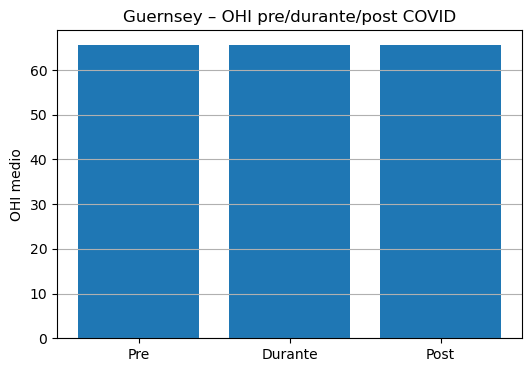

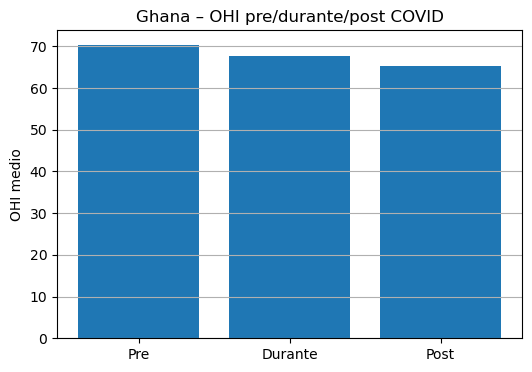

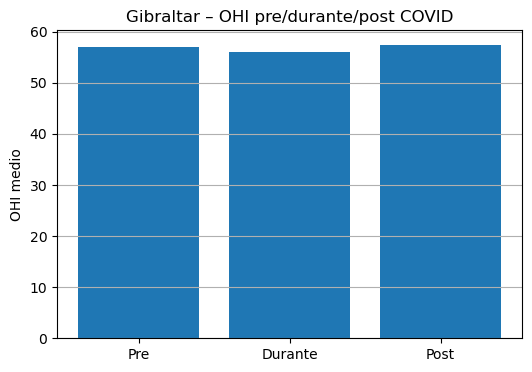

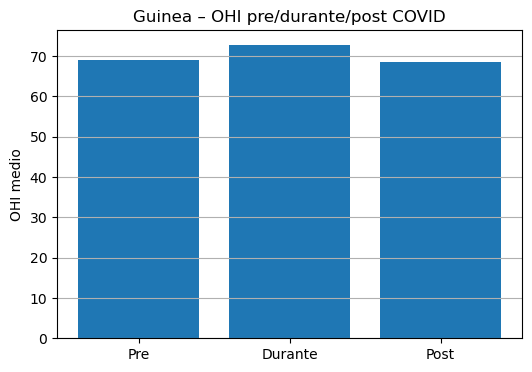

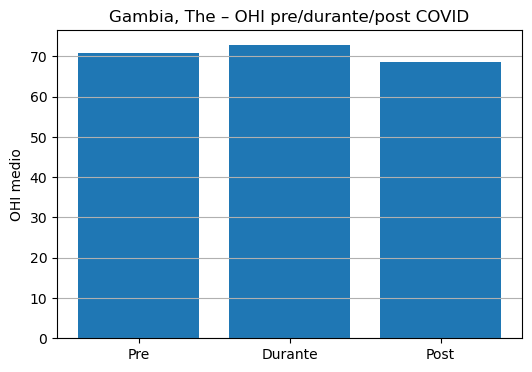

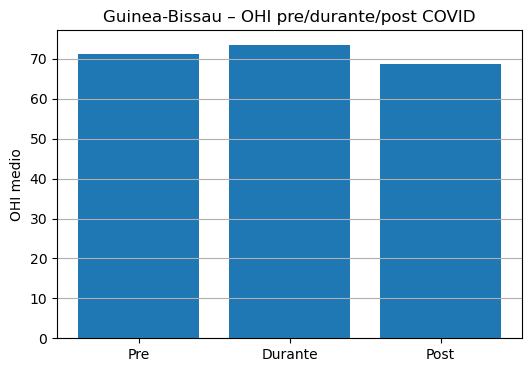

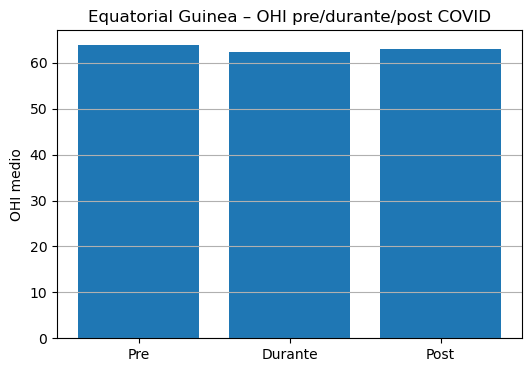

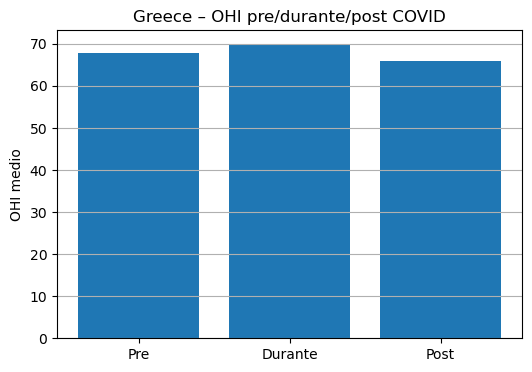

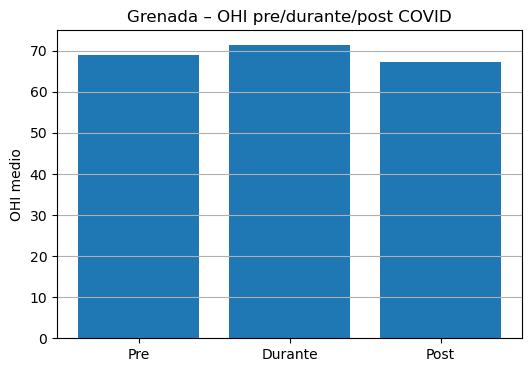

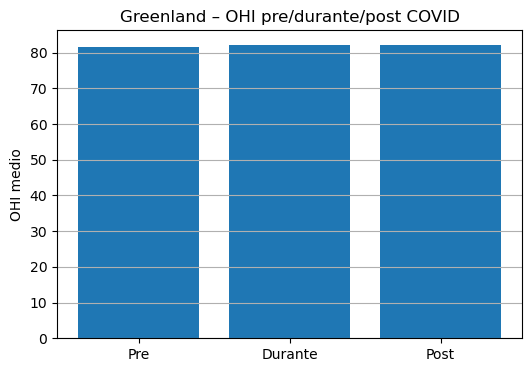

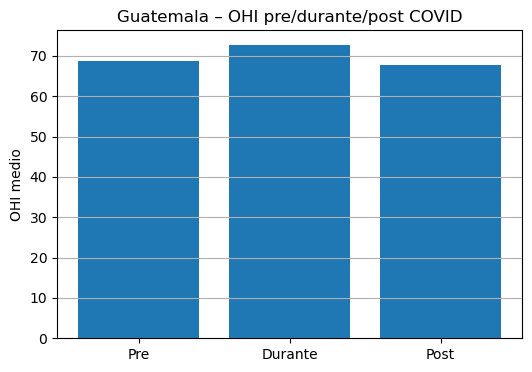

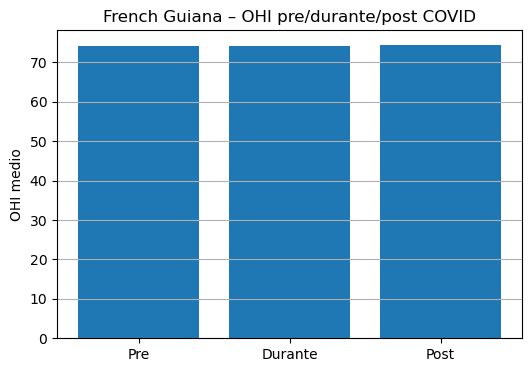

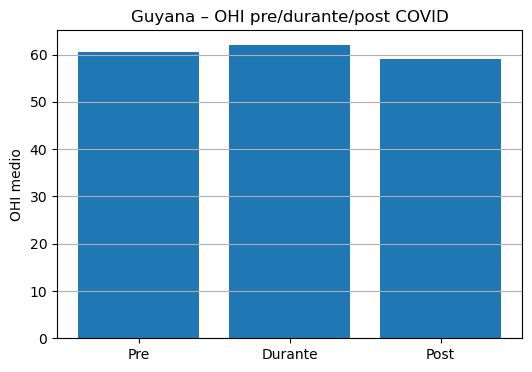

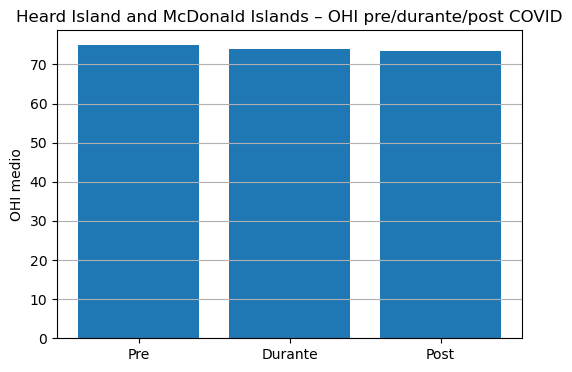

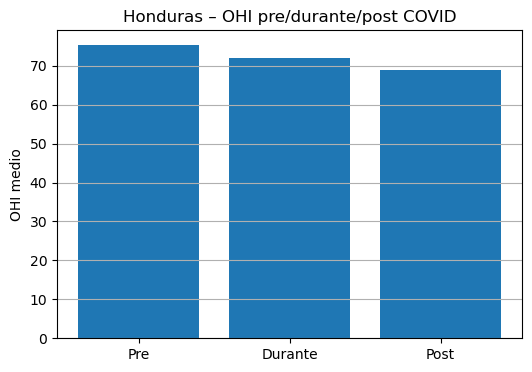

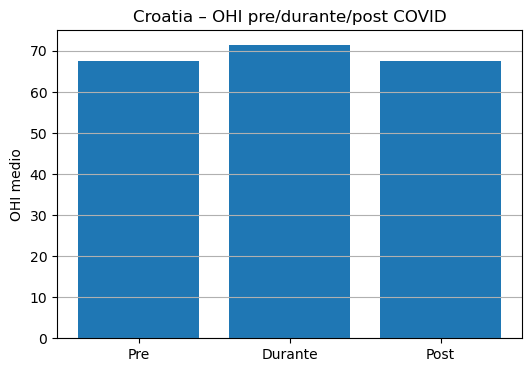

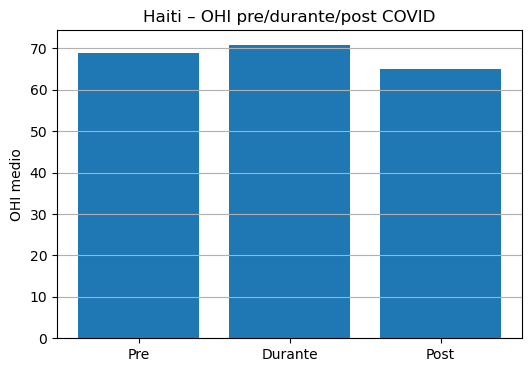

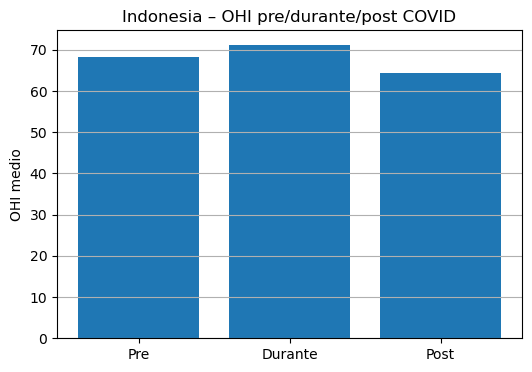

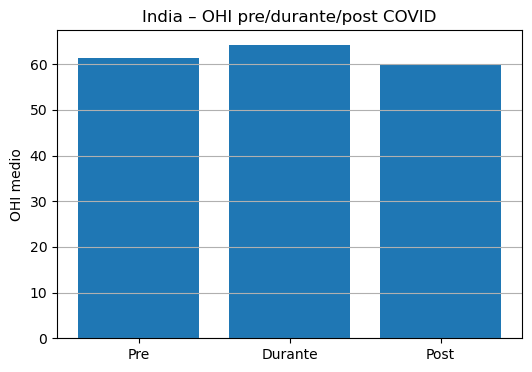

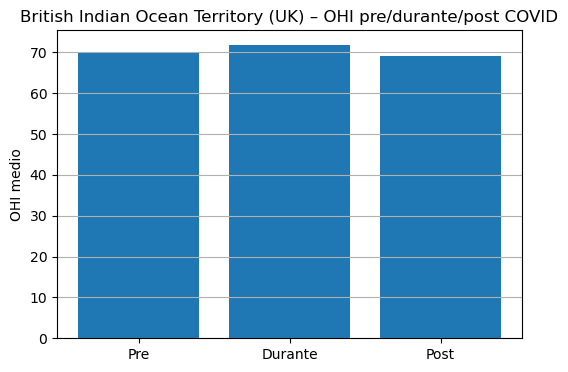

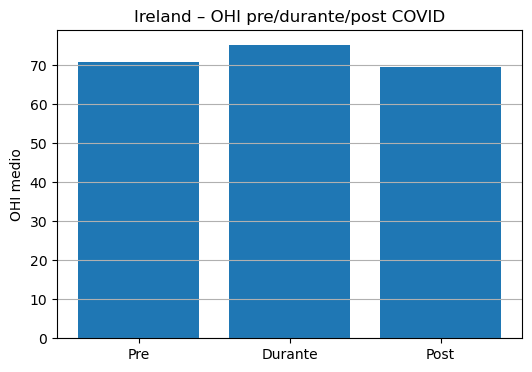

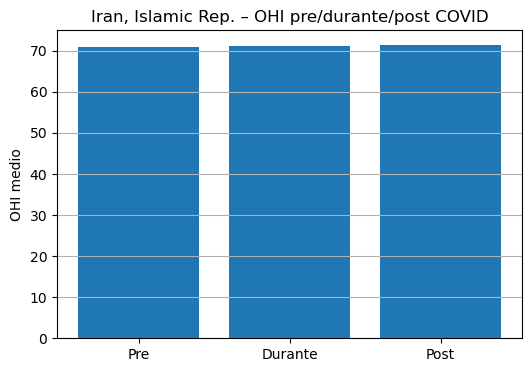

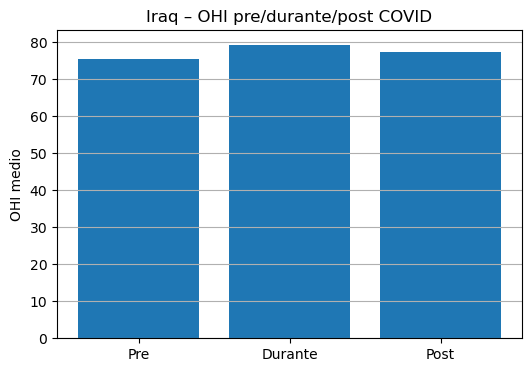

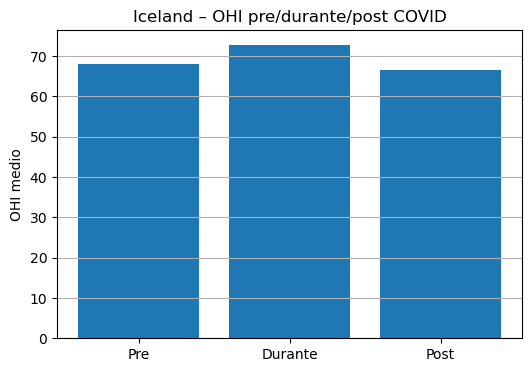

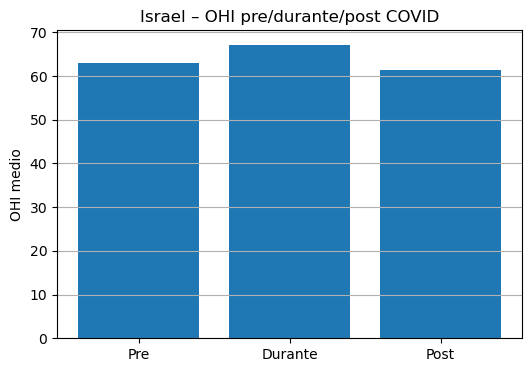

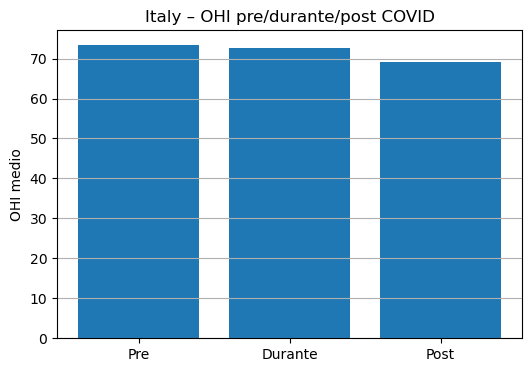

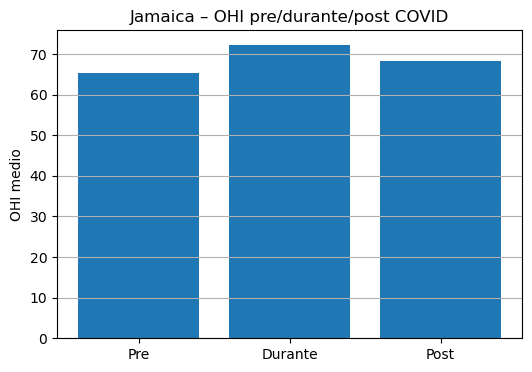

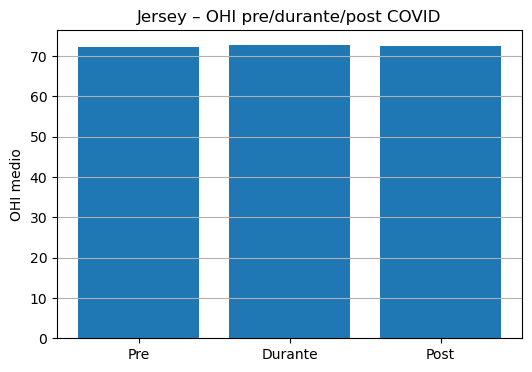

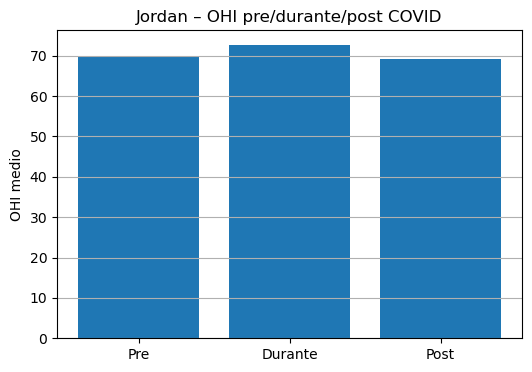

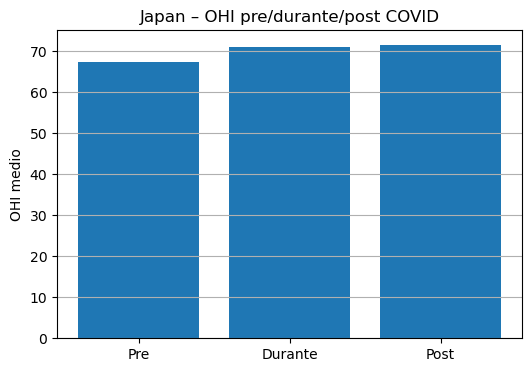

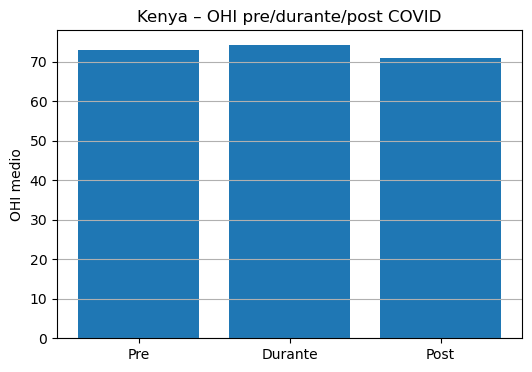

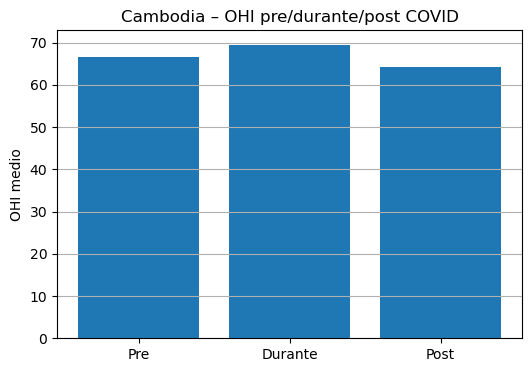

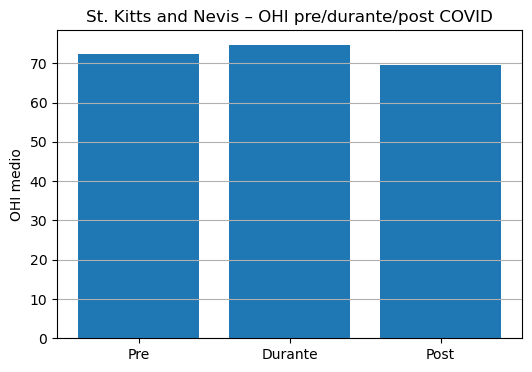

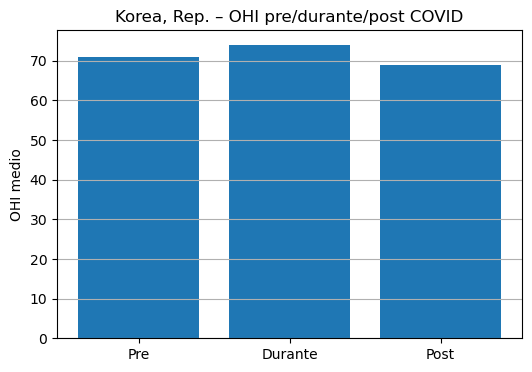

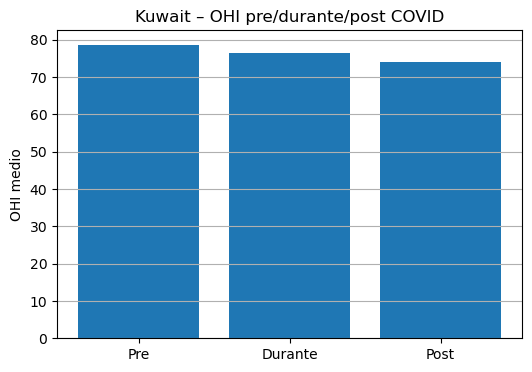

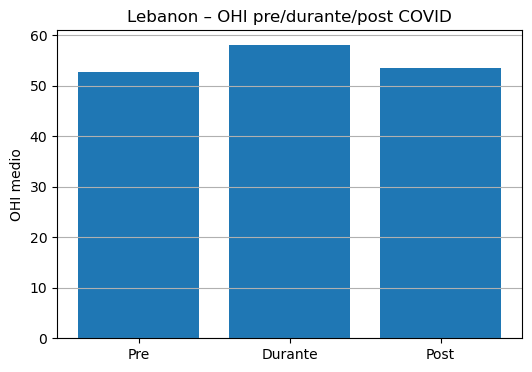

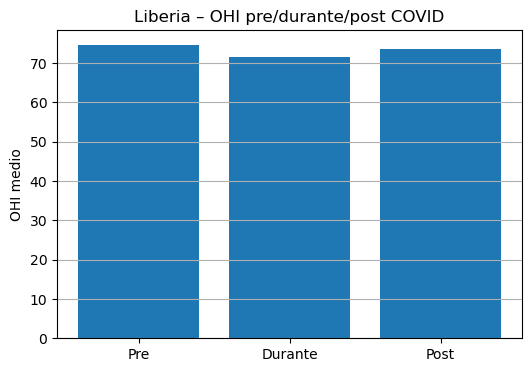

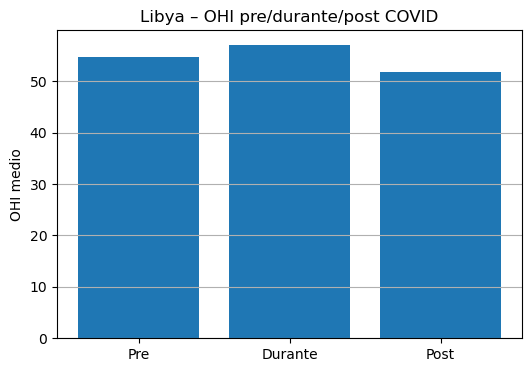

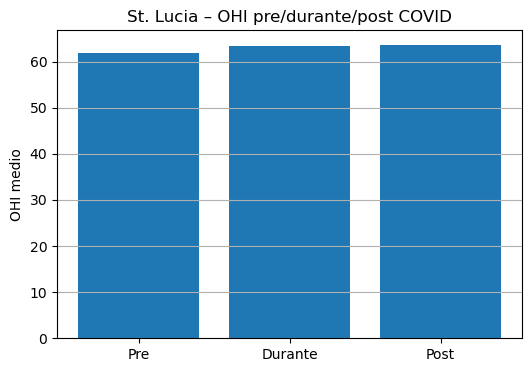

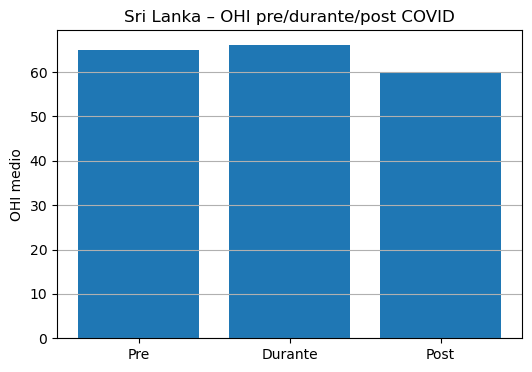

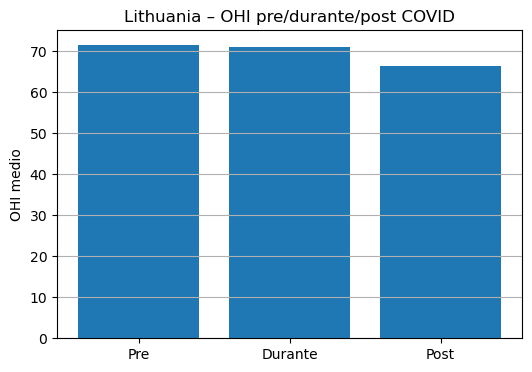

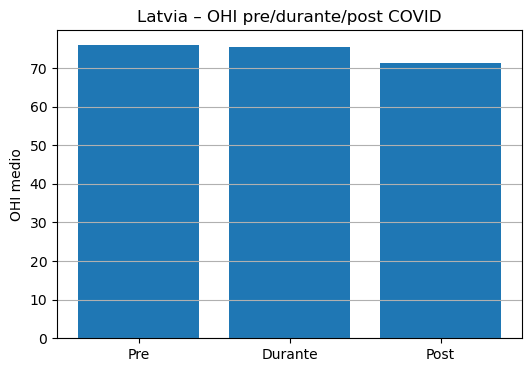

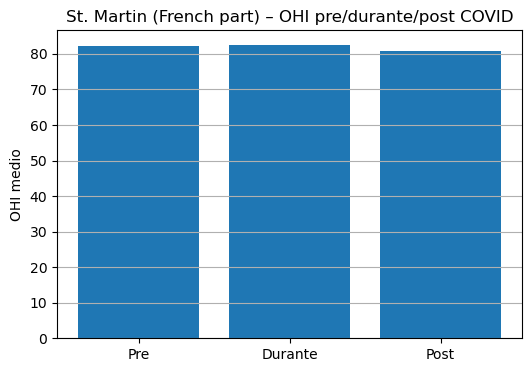

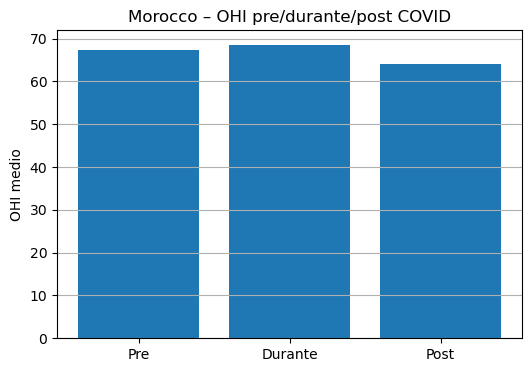

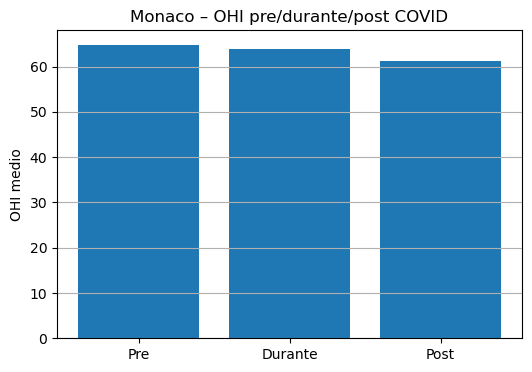

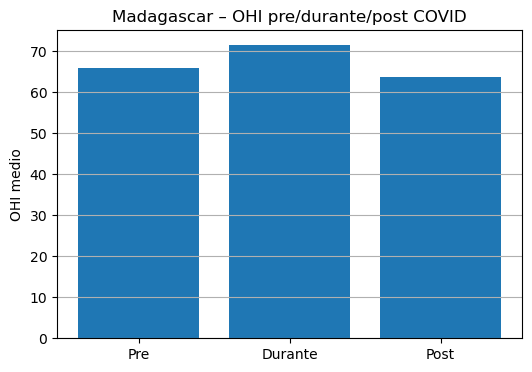

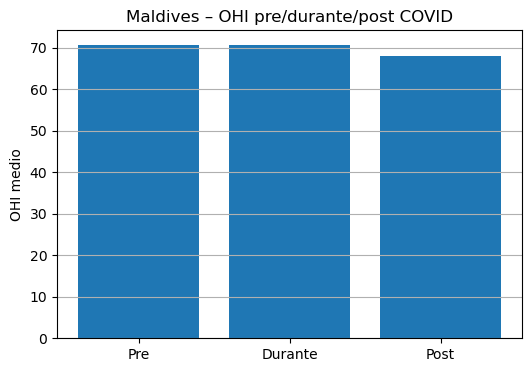

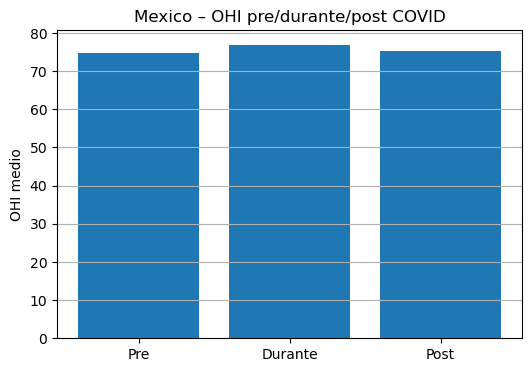

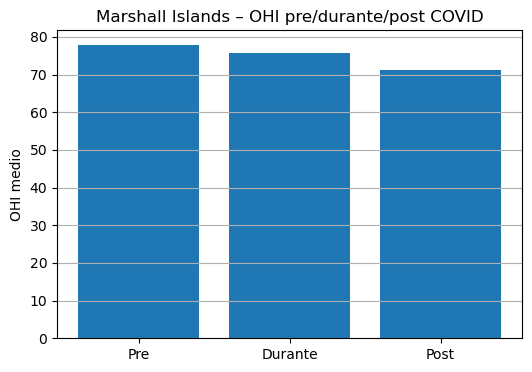

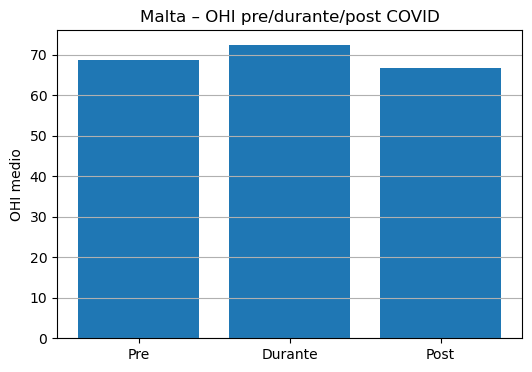

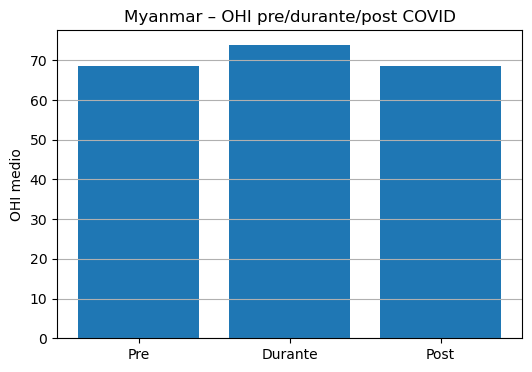

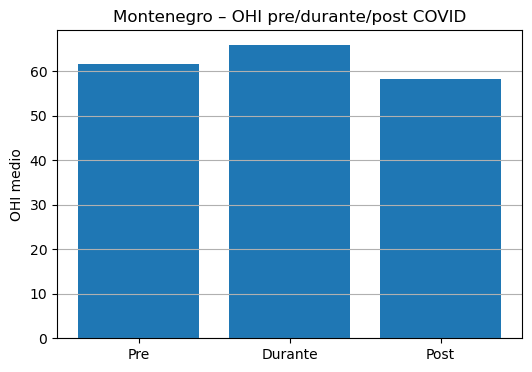

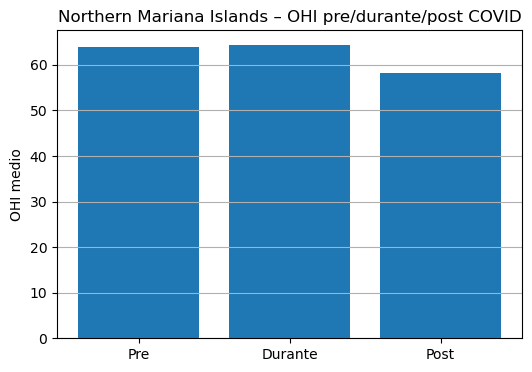

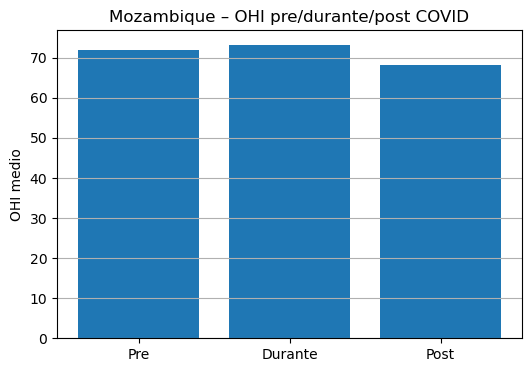

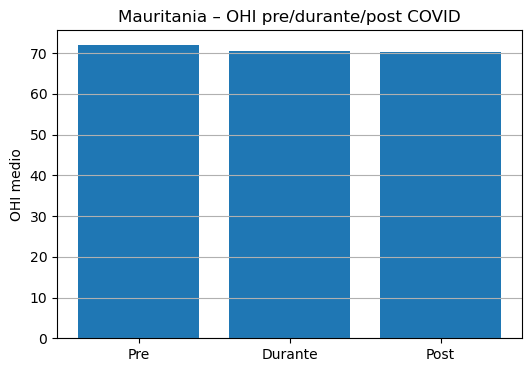

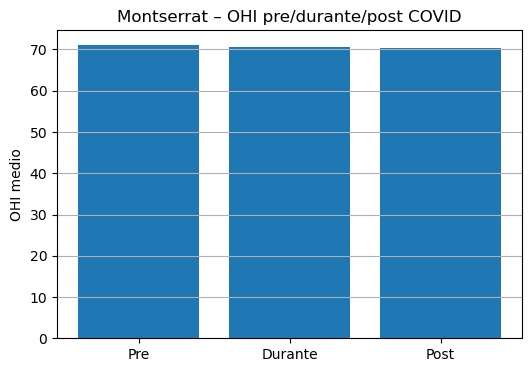

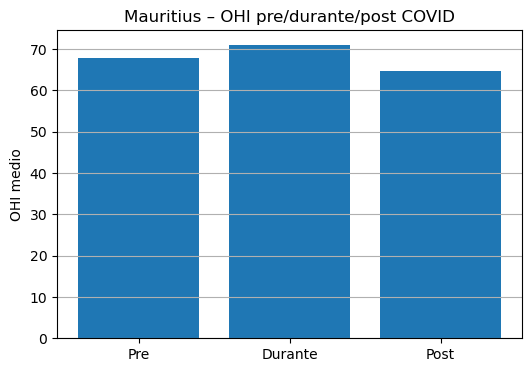

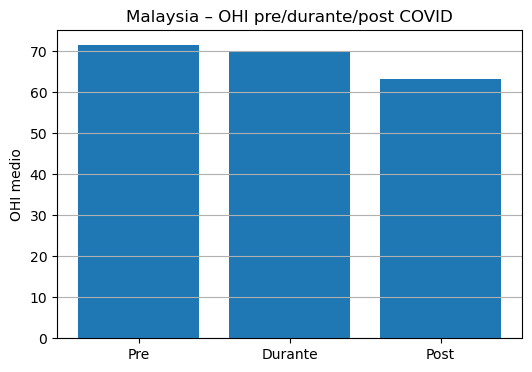

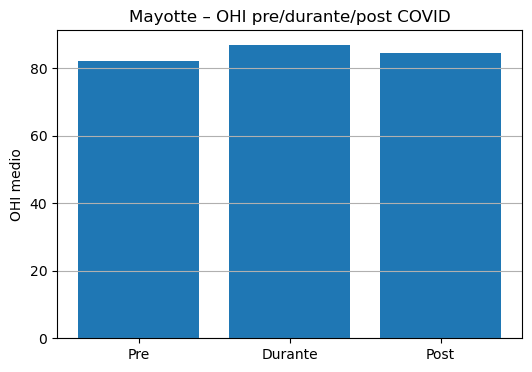

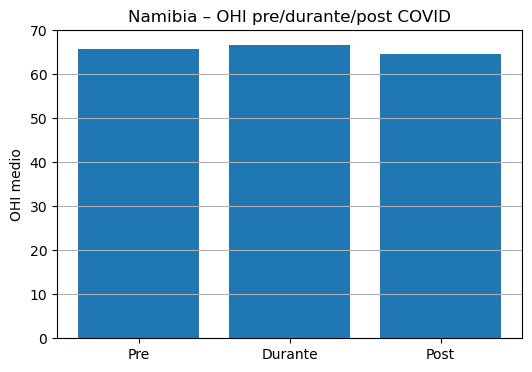

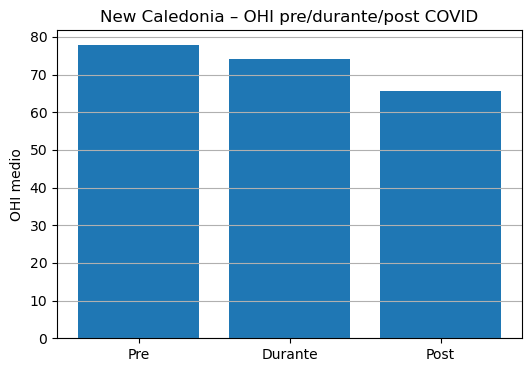

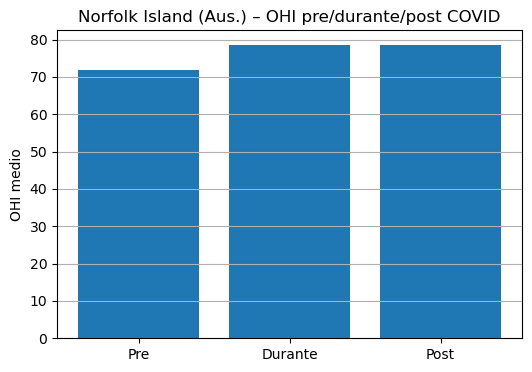

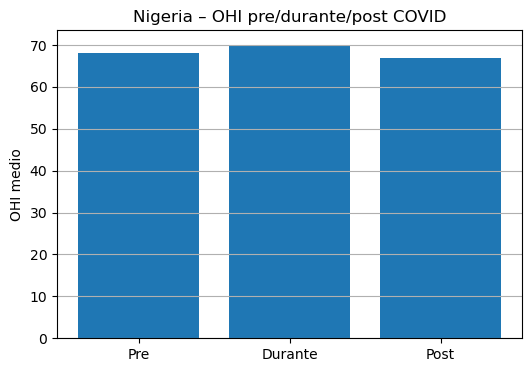

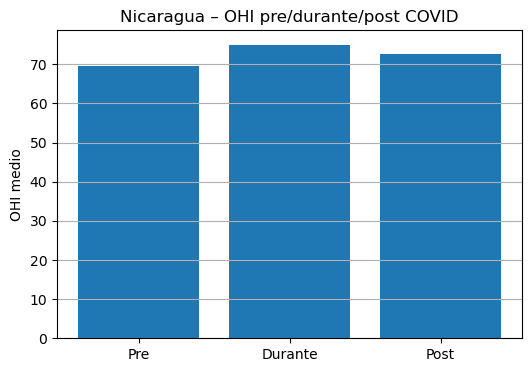

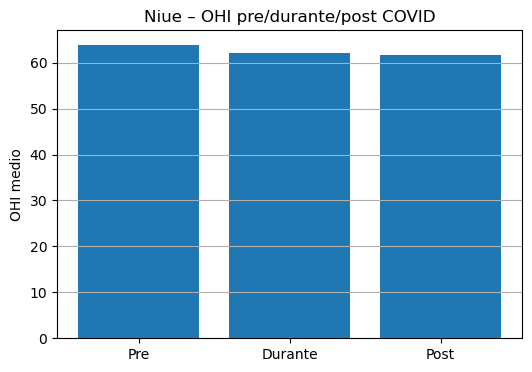

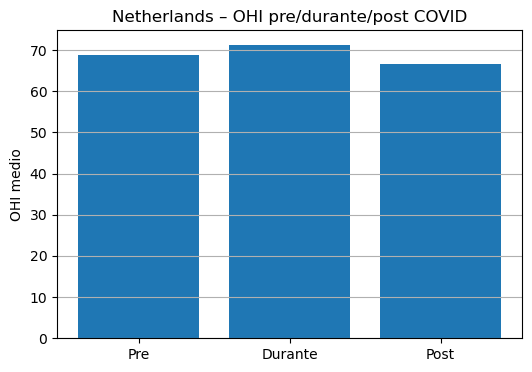

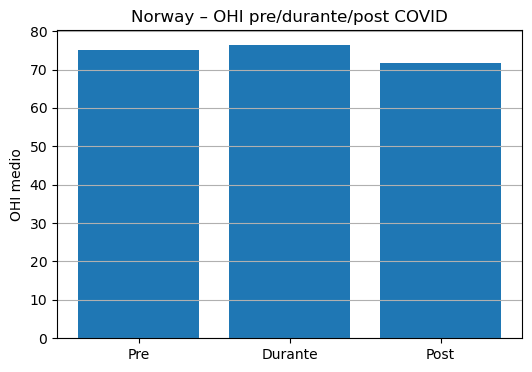

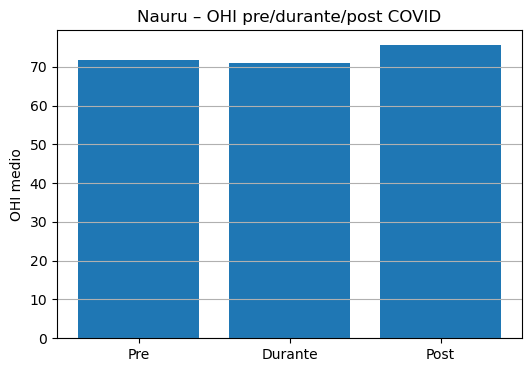

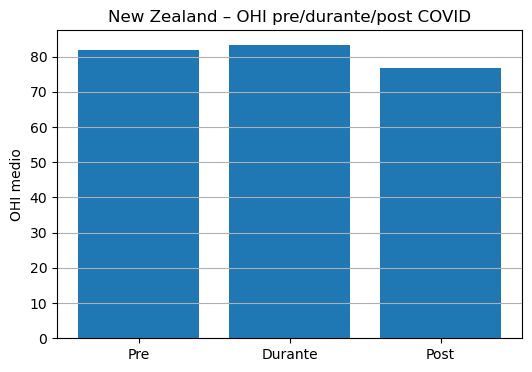

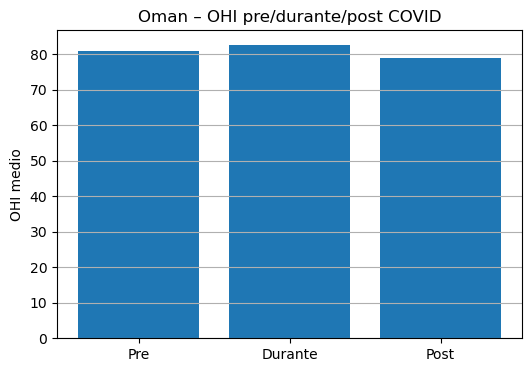

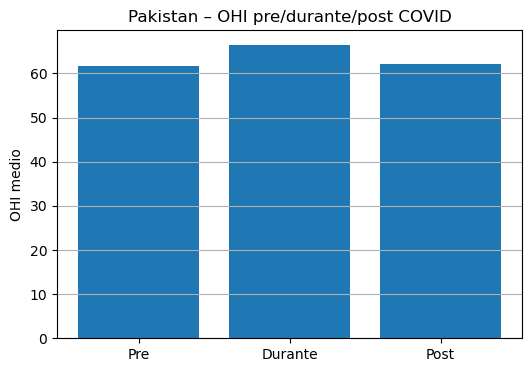

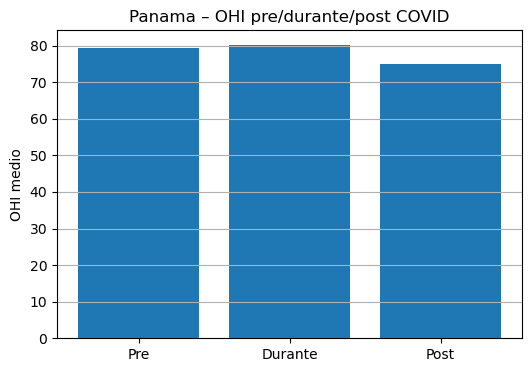

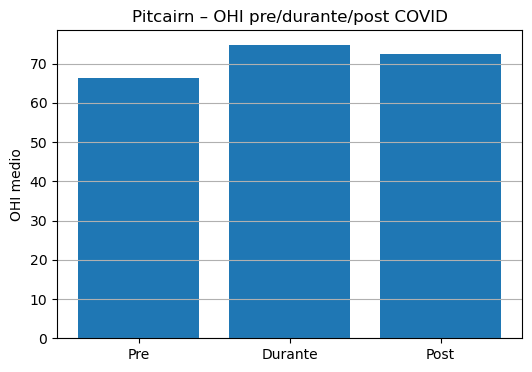

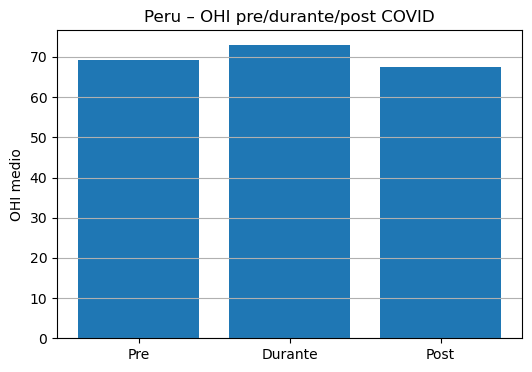

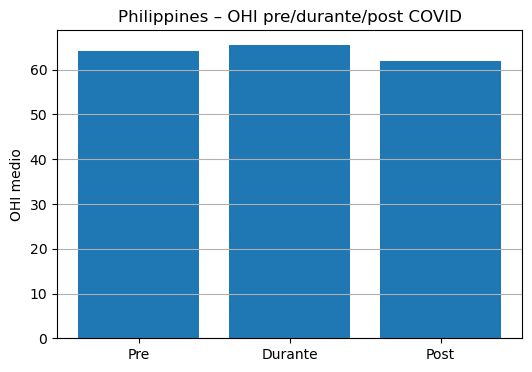

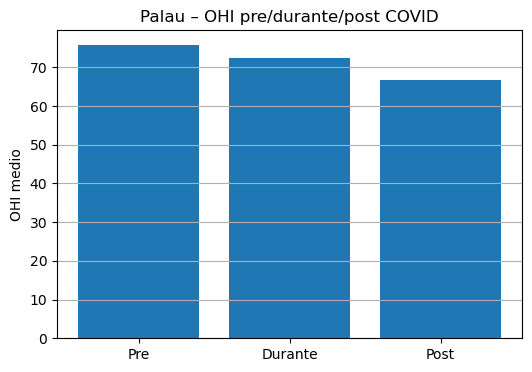

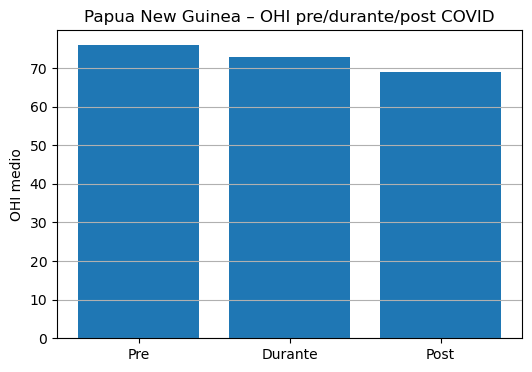

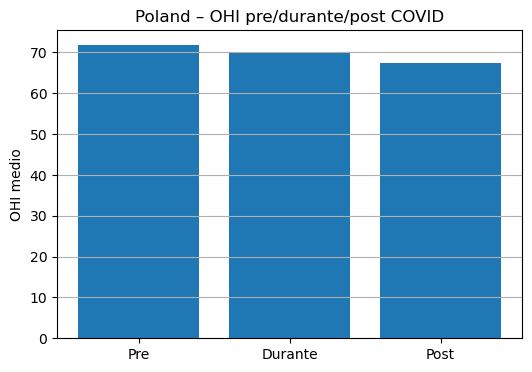

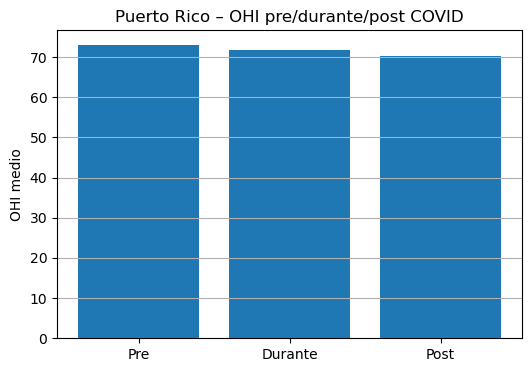

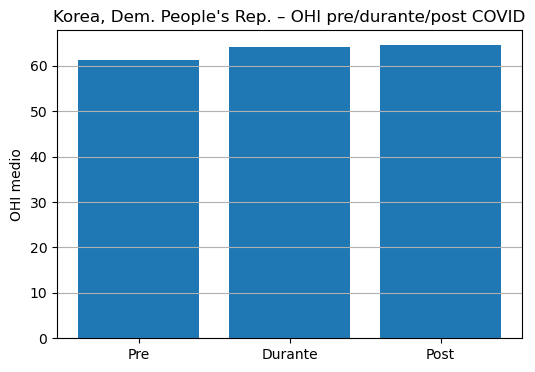

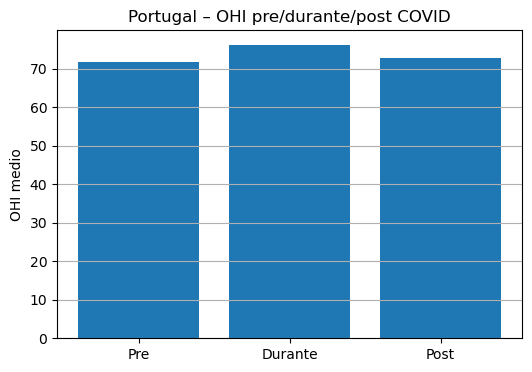

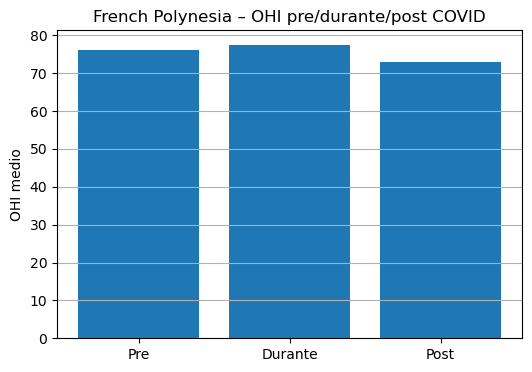

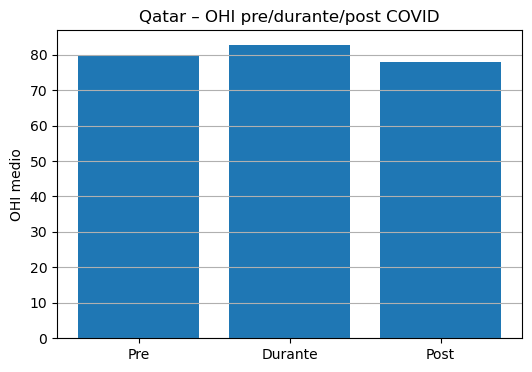

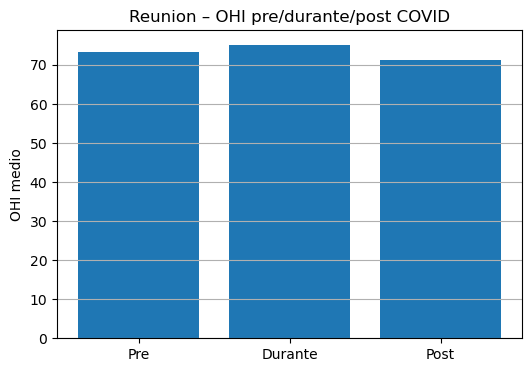

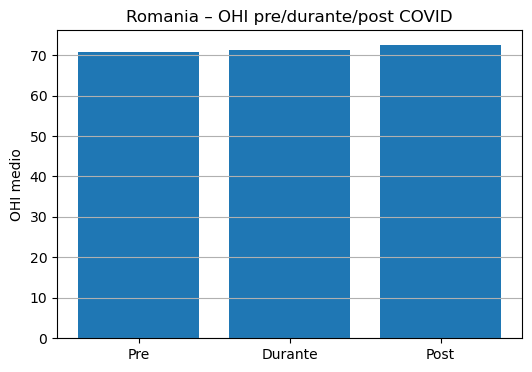

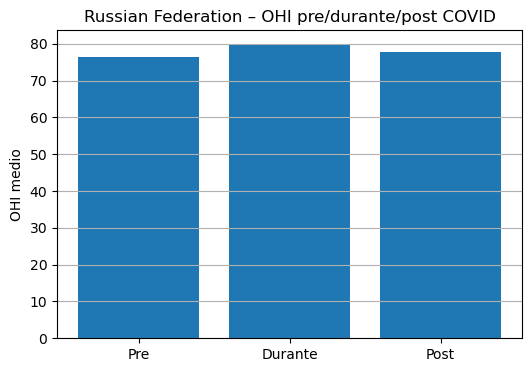

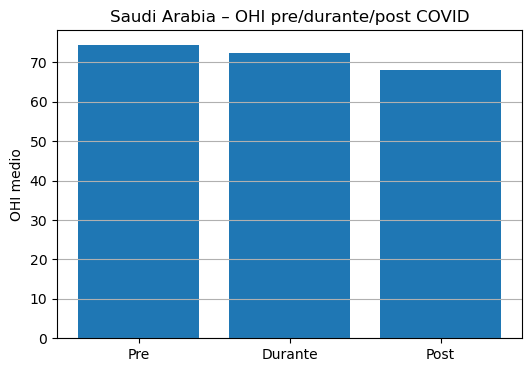

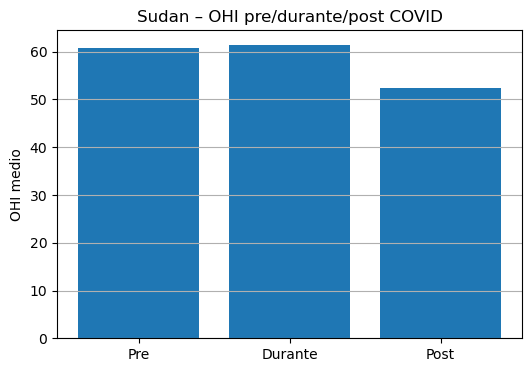

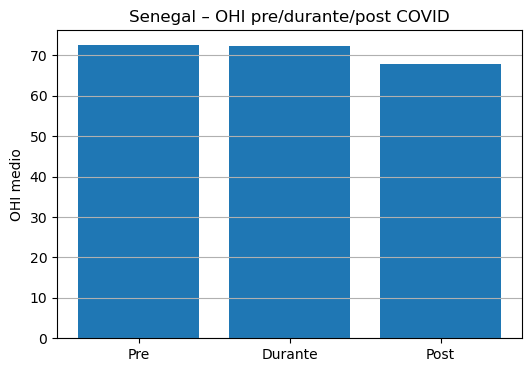

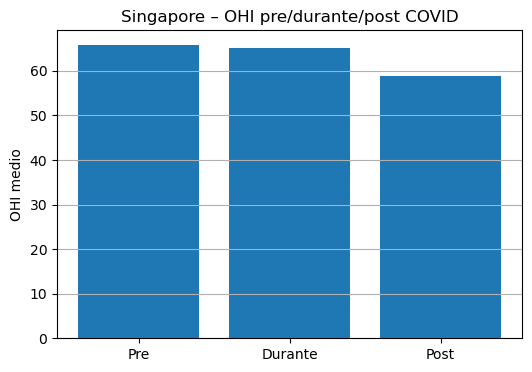

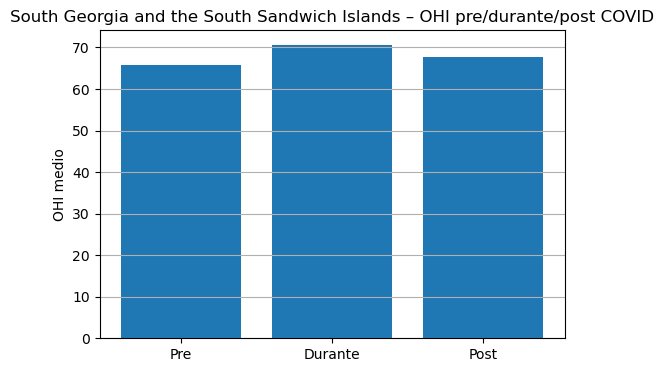

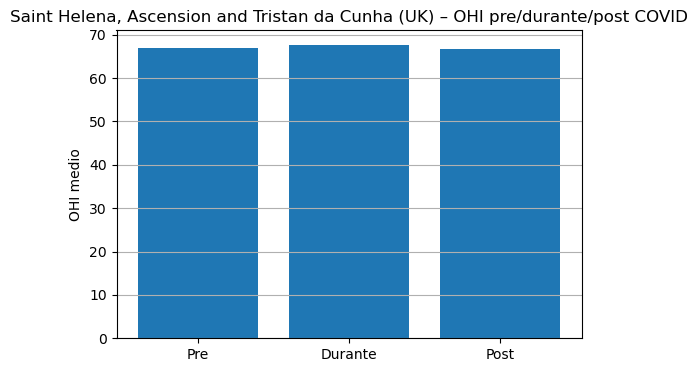

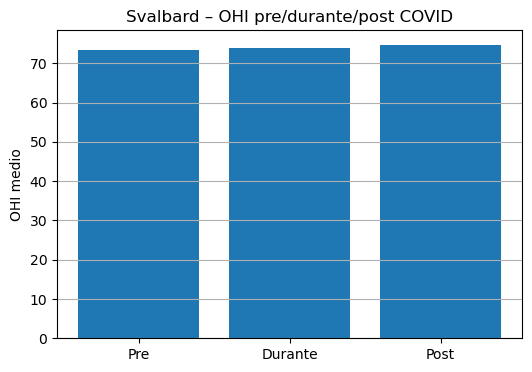

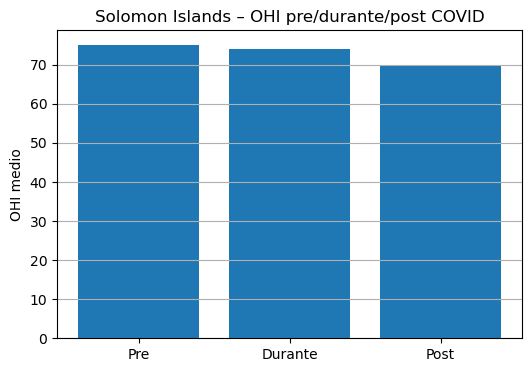

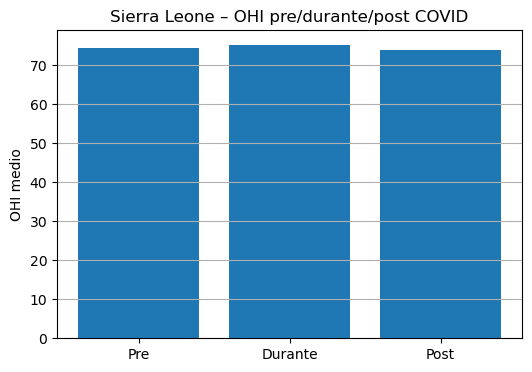

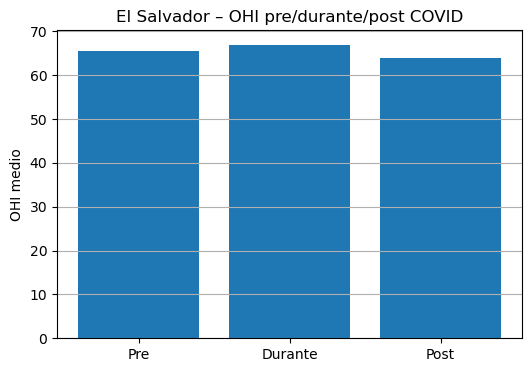

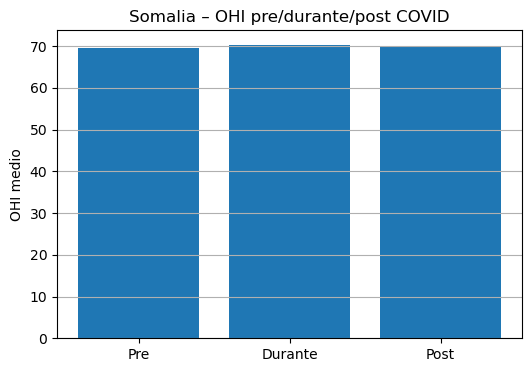

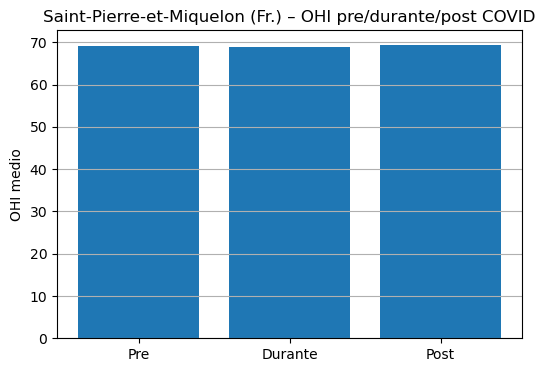

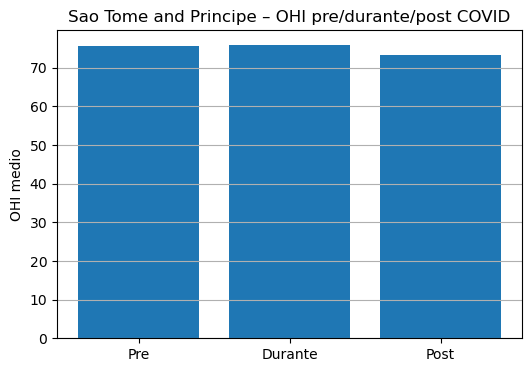

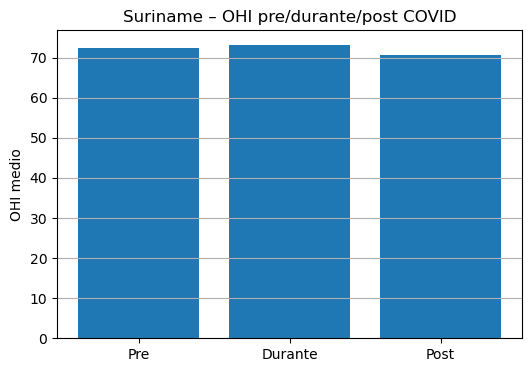

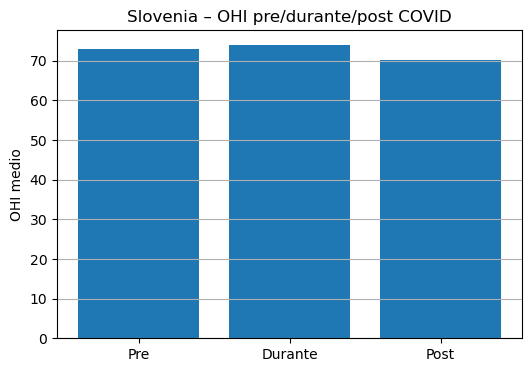

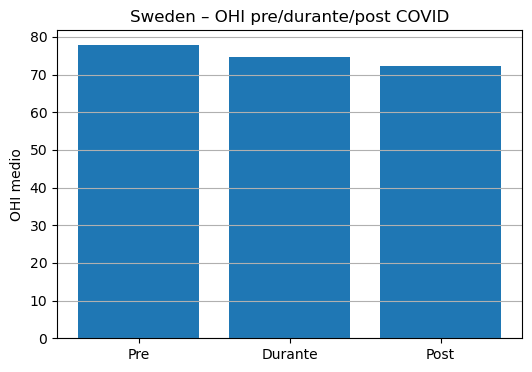

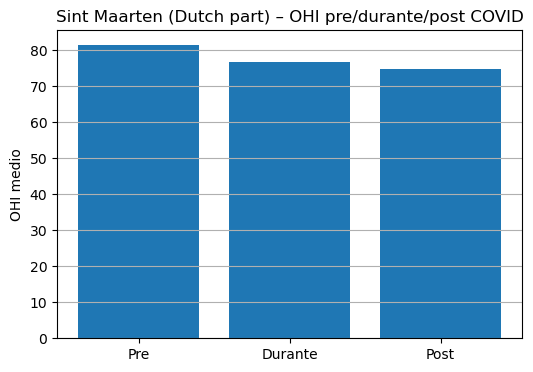

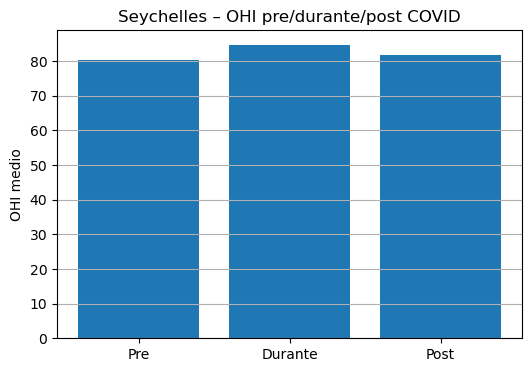

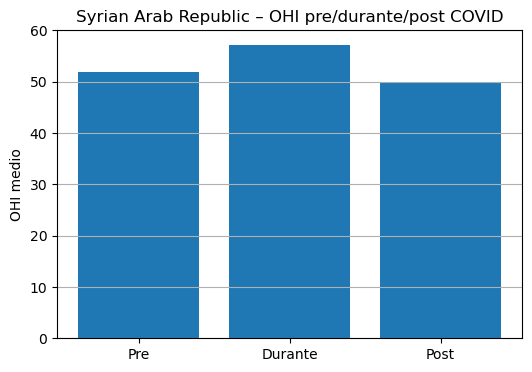

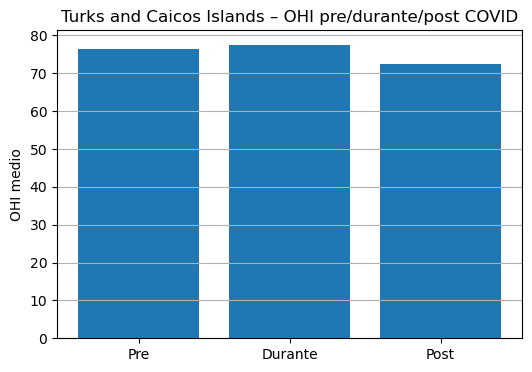

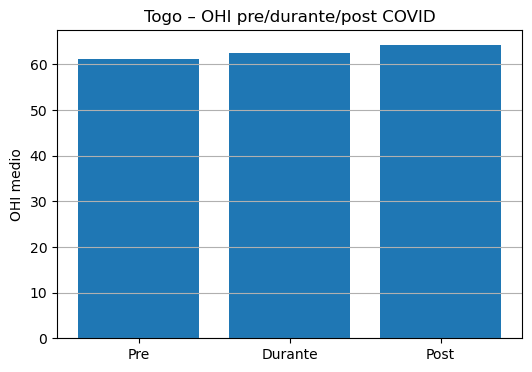

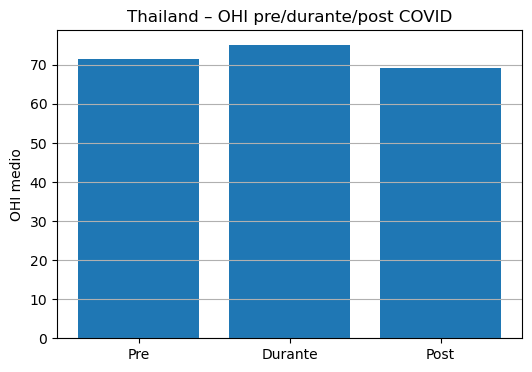

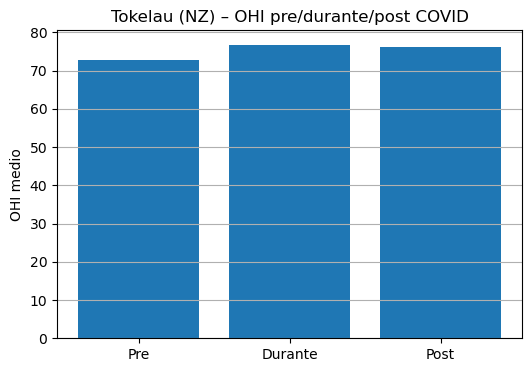

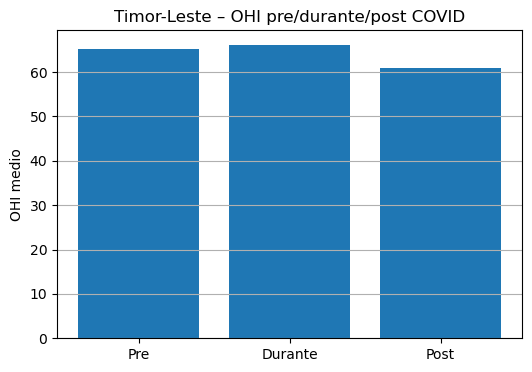

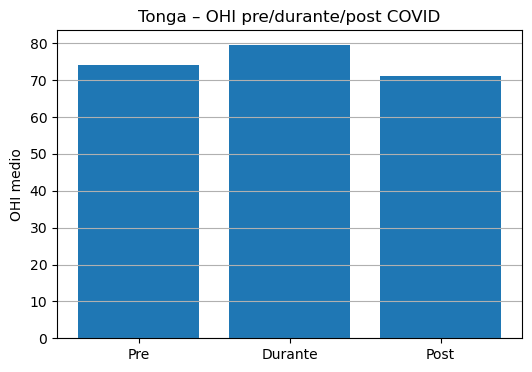

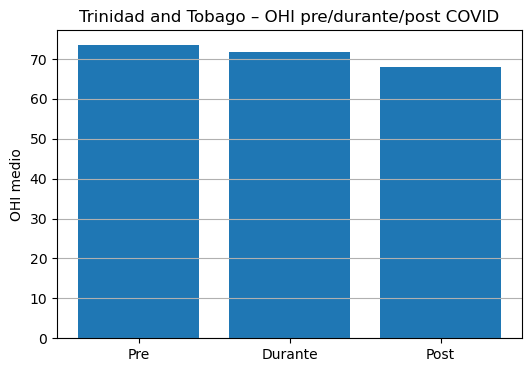

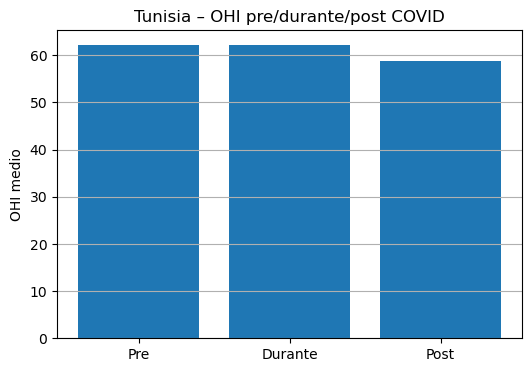

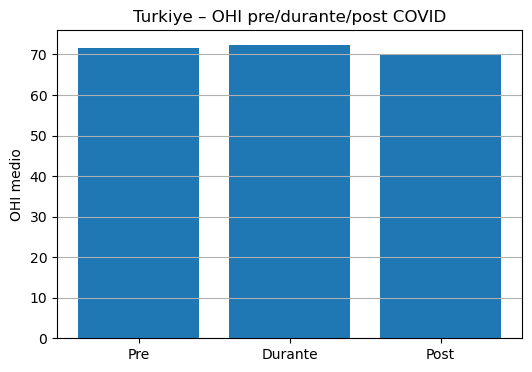

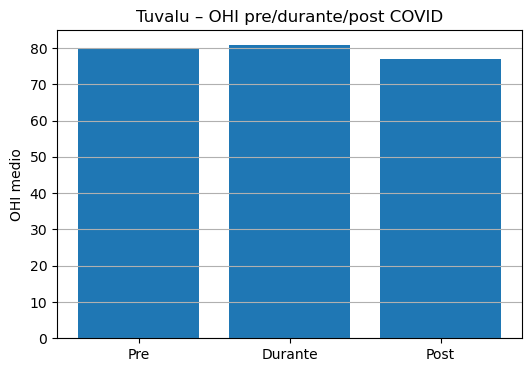

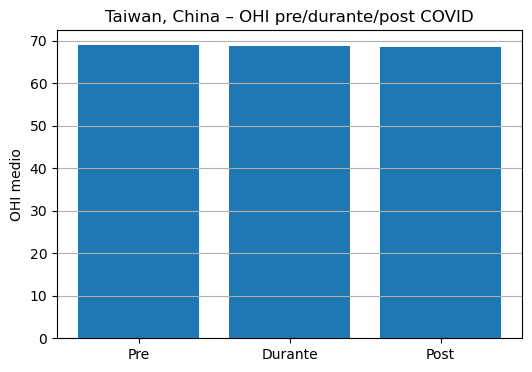

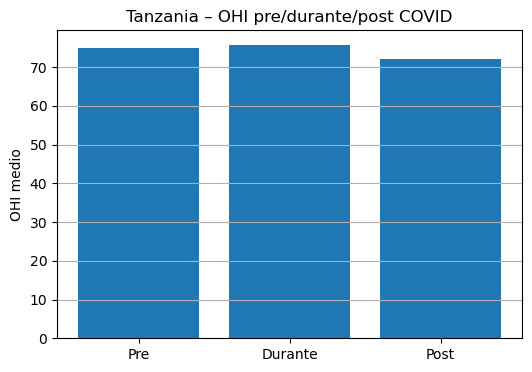

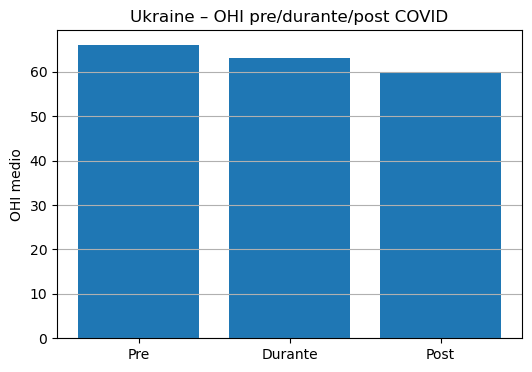

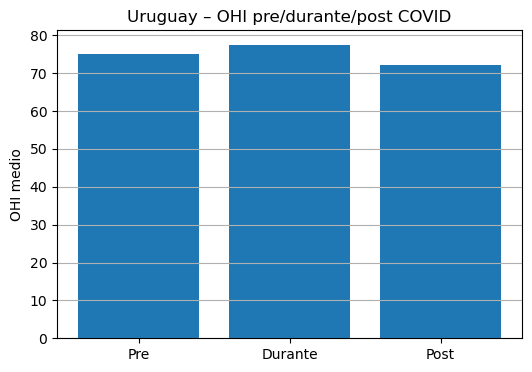

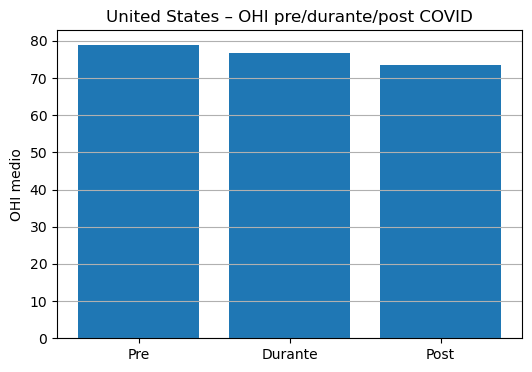

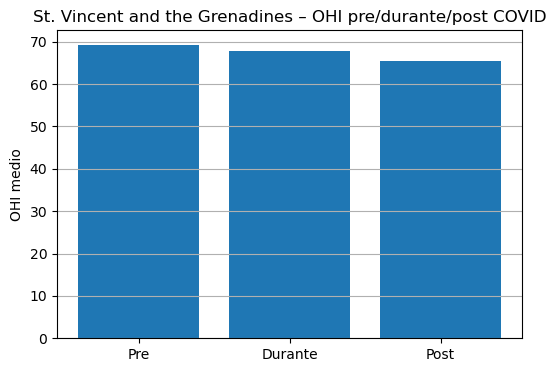

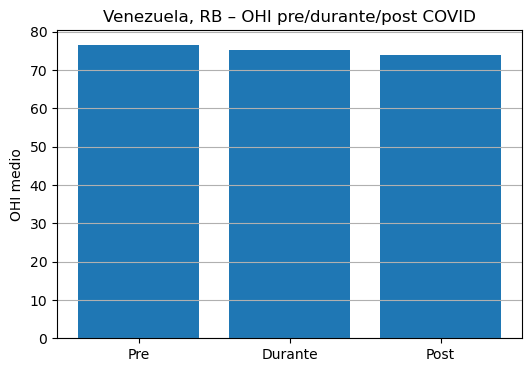

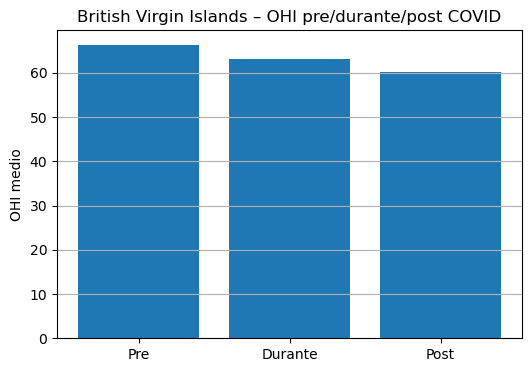

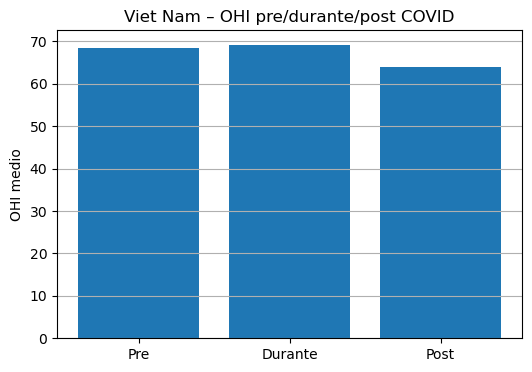

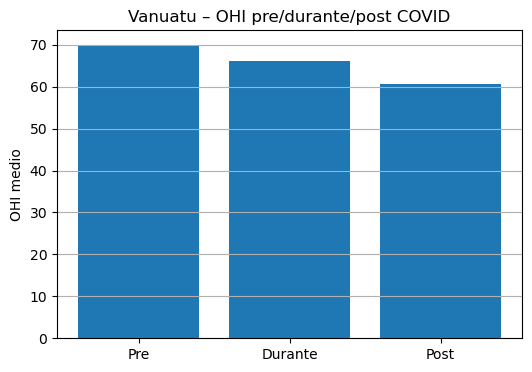

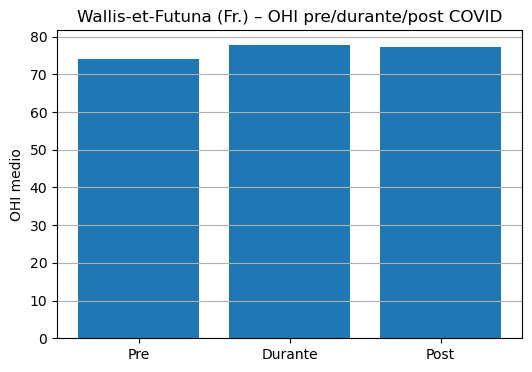

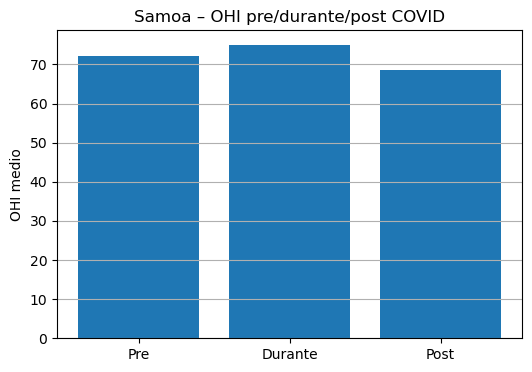

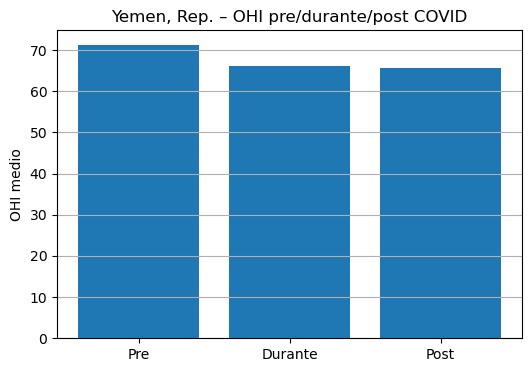

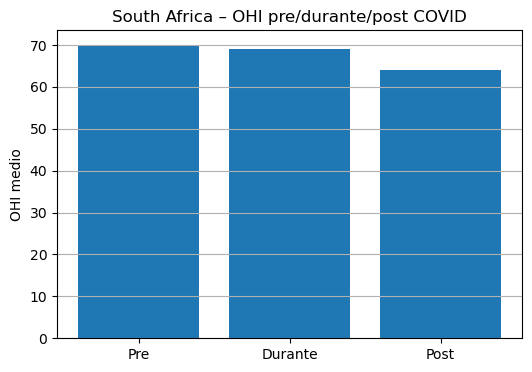

In [242]:
for country in df_new["REF_AREA_LABEL"].unique():
    
    subset = df_new[df_new["REF_AREA_LABEL"] == country]
    
    pre = subset[(subset["Year"] >= 2012) & (subset["Year"] <= 2019)]["OHI"].mean()
    durante = subset[(subset["Year"] >= 2020) & (subset["Year"] <= 2021)]["OHI"].mean()
    post = subset[(subset["Year"] >= 2022) & (subset["Year"] <= 2024)]["OHI"].mean()
    
    plt.figure(figsize=(6,4))
    plt.bar(["Pre", "Durante", "Post"], [pre, durante, post])
    plt.title(f"{country} – OHI pre/durante/post COVID")
    plt.ylabel("OHI medio")
    plt.grid(axis="y")
    plt.show()


# --- Machine Learning ---

## Modello supervisionato

- Obiettivo: previsione dell’OHI a partire dall’anno
- Algoritmo: Regressione Lineare

In [243]:
X = df_new[["Year", "REF_AREA_LABEL"]]  # Features: anno + paese
y = df_new["OHI"]

preprocessor = ColumnTransformer(
    transformers=[
        ("poly", PolynomialFeatures(degree=2, include_bias=False), ["Year"]), # Trasformo l'anno in un polinomio di grado 2 -> l'OHI non cresce in modo lineare nel tempo
        ("cat", OneHotEncoder(), ["REF_AREA_LABEL"]) # Trasformo i paesi in variabili binarie 0/1
    ]
)

model = Pipeline([ # Unisco le trasformazioni e il modello in un unico oggetto
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)
pred = model.predict(X_test)

mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("MSE:", mse)
print("R2:", r2)


MSE: 9.143777441689526
R2: 0.7707785432385884


### Grafico delle previsioni

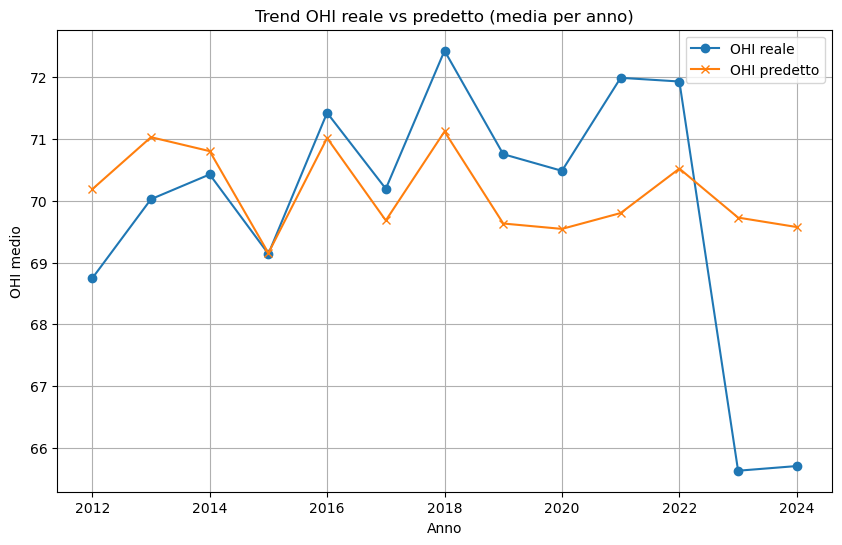

In [244]:
df_pred = X_test.copy()
df_pred["y_true"] = y_test
df_pred["y_pred"] = pred

mean_pred = df_pred.groupby("Year")[["y_true","y_pred"]].mean()

plt.figure(figsize=(10,6))
plt.plot(mean_pred.index, mean_pred["y_true"], label="OHI reale", marker='o')
plt.plot(mean_pred.index, mean_pred["y_pred"], label="OHI predetto", marker='x')

plt.title("Trend OHI reale vs predetto (media per anno)")
plt.xlabel("Anno")
plt.ylabel("OHI medio")
plt.legend()
plt.grid(True)
plt.show()

### Previsione 2025/2030

In [245]:
future_years = [2025, 2026, 2027, 2028, 2029, 2030]
countries = df_new["REF_AREA_LABEL"].unique()

# Creo il dataframe combinando ogni anno con ogni paese
future_df = pd.DataFrame([
    {"Year": year, "REF_AREA_LABEL": country}
    for year in future_years
    for country in countries
])

# Previsioni
future_df["OHI_pred"] = model.predict(future_df)

display(future_df)

,Year,REF_AREA_LABEL,OHI_pred
0,2025,Aruba,72.696487
1,2025,Angola,61.711003
2,2025,Anguilla,69.925767
3,2025,Albania,66.664754
4,2025,Netherlands Antilles,75.193160
...,...,...,...
1153,2030,Vanuatu,66.970471
1154,2030,Wallis-et-Futuna (Fr.),74.110574
1155,2030,Samoa,70.902738
1156,2030,"Yemen, Rep.",67.954806


## Modello non supervisionato

- Obiettivo: raggruppare i paesi in cluster secondo i loro valori OHI
- Algoritmo: K-means

In [246]:
# Trasformo ogni paese in un vettore dei suoi anni
pivot_ml = df.pivot_table(
    index="REF_AREA_LABEL",
    values=[str(y) for y in range(2012, 2025)]
)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(pivot_ml)

pivot_ml["Cluster"] = clusters

print("SSE:", kmeans.inertia_) # somma dei quadrati delle distanze dei punti dal centroide del cluster -> Più bassa -> cluster più compatto

score = silhouette_score(pivot_ml.drop("Cluster", axis=1), pivot_ml["Cluster"])
print("Silhouette score:", score) # Valuto quanto i cluster sono ben separati -> 1 = ottimo | 0 = sovrapposizione totale (per il plot di seguito)

SSE: 28174.126801749662
Silhouette score: 0.3854335581037306


### Visualizzazione

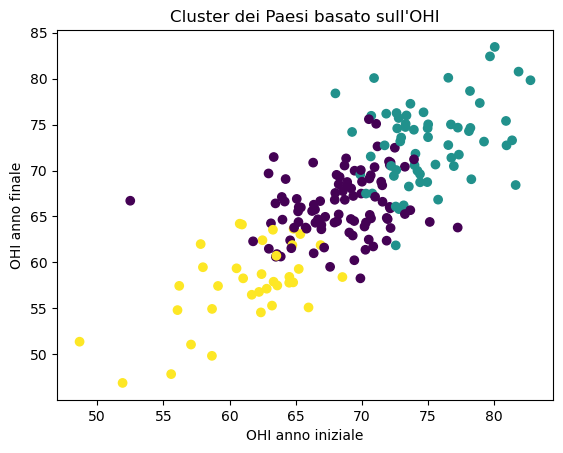

In [247]:
plt.scatter(
    pivot_ml.iloc[:, 0], pivot_ml.iloc[:, -2],
    c=pivot_ml["Cluster"]
)

plt.xlabel("OHI anno iniziale")
plt.ylabel("OHI anno finale")
plt.title("Cluster dei Paesi basato sull'OHI")
plt.show()

#### Note

- Punti vicini tra loro -> paesi simili come andamento OHI dal 2012 al 2023
- Punti distanti -> paesi con andamento molto diverso
- Colori diversi -> cluster calcolati automaticamente da K-means, quindi gruppi di paesi “simili” secondo la serie temporale OHI
- Bisettrice y=x -> nessun cambiamento tra anno iniziale e finale
- Sopra la diagonale -> OHI migliorato
- Sotto la diagonale -> OHI peggiorato

## XGBoost

In [ ]:

X = df_new[["Year", "REF_AREA_LABEL"]]
y = df_new["OHI"]

X_encoded = pd.get_dummies(X, columns=["REF_AREA_LABEL"], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)


model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)


y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)

MSE: 10.345264860545937
R2: 0.7406589675832247


In [252]:
future_years = [2025, 2026, 2027, 2028, 2029, 2030]
countries = df_new["REF_AREA_LABEL"].unique()

# Creo il dataframe combinando ogni anno con ogni paese
future_df = pd.DataFrame([
    {"Year": year, "REF_AREA_LABEL": country}
    for year in future_years
    for country in countries
])

future_encoded = pd.get_dummies(future_df, columns=["REF_AREA_LABEL"], drop_first=True)
future_df["OHI_pred"] = model.predict(future_encoded)

display(future_df)

,Year,REF_AREA_LABEL,OHI_pred
0,2025,Aruba,68.150185
1,2025,Angola,60.743458
2,2025,Anguilla,67.631027
3,2025,Albania,67.631027
4,2025,Netherlands Antilles,71.627579
...,...,...,...
1153,2030,Vanuatu,67.631027
1154,2030,Wallis-et-Futuna (Fr.),72.268494
1155,2030,Samoa,67.631027
1156,2030,"Yemen, Rep.",67.631027
